### A. Definisi generative adversarial network (GAN)

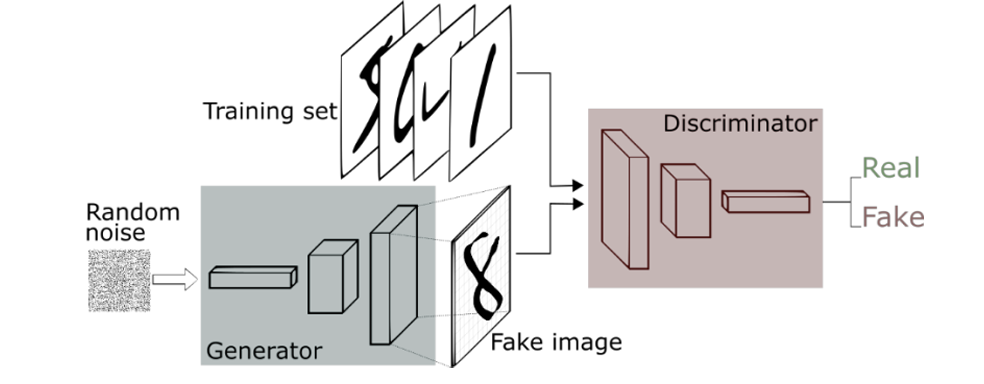 GAN adalah teknologi yang digunakan untuk menghasilkan data baru yang menyerupai data yang sudah ada dengan memanfaatkan dua jaringan neural yaitu Generator & Diskriminator.

Cara kerja:
1. Generator: menerima input berupa Random Noise (vektor acak) yang kemudian diproses oleh lapisan-lapisan jaringan saraf. Generator kemudian menghasilkan gambar palsu pada contoh gambar, Generator mencoba membuat gambar yang menyerupai data training

2. Discriminator (Juri): menerima dua jenis input bersamaan, satu adalah gambar asli dari training set dan juga gambar palsu yang dibuat oleh generator. Discriminator kemudian menganalisis fitur-fitur dari gambar yang masuk menggunakan neural networknya sendiri.

Discriminator akan mengeluarkan keputusan akhir (klasifikasi), yaitu mendeteksi apakah gambar tersebut Real (Asli) atau Fake (Palsu).

Tujuan dari kedua kombinasi jaringan saraf ini adalah generator terus belajar membuat gambar palsu yang semakin mirip dengan gambar asli untuk kelabui discriminator dan discriminator terus belajar agar semakin pintar membandingkan mana yang gambar asli vs gambar palsu buatan dari generator.

### B. Membuat GAN Architecture

#### B.1 Load Library & Data

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

import os
import cv2

In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(print(f"Using device: {device}"))

Using device: cuda
None


In [ ]:
# from google.colab import drive
# drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data_dir_storage = Path('/content/drive/MyDrive/Colab Notebooks/Dataset DL UAS/overhead/storage_tank')
data_dir_parking = Path('/content/drive/MyDrive/Colab Notebooks/Dataset DL UAS/overhead/parking_lot')
IMG_SIZE = 28

#load & scale data
def load_data(data_dir, class_label):
  images = []
  labels = []

  for img_path in data_dir.glob("*.jpg"):
      # Load gambar menggunakan libary OpenCV
      img = cv2.imread(str(img_path))

      if img is not None:
          # Ubah warna ke b&w saat membaca
          img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

          # Resize gambar agar ukuran selalu konsisten
          img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

          images.append(img)
          labels.append(class_label)  #beri label 0, 1 (storage_tank, parking lot)

  # Konversi ke NumPy Array
  X = np.array(images, dtype=np.float32)
  y = np.array(labels)

  # Scaling & Normalisasi: Mengubah nilai piksel dari [0, 255] menjadi [0, 1]
  # Memaksa setiap gambar memiliki rentang kontras [0, 1] yang sempurna secara independen
  for i in range(len(X)):
      min_val = np.min(X[i])
      max_val = np.max(X[i])
      if max_val - min_val > 0:
          X[i] = (X[i] - min_val) / (max_val - min_val)
      else:
          X[i] = X[i] * 0.0 #jika ada gambar hitam polos, biarkan

  print(f"Total data berhasil di-load: {X.shape[0]} gambar")
  print(f"Shape dataset setelah scaling: {X.shape}")
  return X, y

In [5]:
X1, y1 = load_data(data_dir_storage, 0)
X2, y2 = load_data(data_dir_parking, 1)

Total data berhasil di-load: 1000 gambar
Shape dataset setelah scaling: (1000, 28, 28)
Total data berhasil di-load: 1000 gambar
Shape dataset setelah scaling: (1000, 28, 28)


In [ ]:
#Gabungkan keduanya karena GAN bisa mempelajari keduanya bersamaan
X_train = np.concatenate((X1, X2), axis=0)
y_train = np.concatenate((y1, y2), axis=0)
print(f"\nTotal Gabungan Dataset: X shape = {X_train.shape}, y shape = {y_train.shape}")


Total Gabungan Dataset: X shape = (2000, 28, 28), y shape = (2000,)


In [ ]:
import torch
from torch.utils.data import Dataset, DataLoader

class OverheadDataset(Dataset): #Kelas preprocessing agar data gambar dapat dibaca dengan benar oleh GAN
    def __init__(self, X, y):
        # Menambah dimensi channel (Batch, Channel, Height, Width) -> (B, 1, 28, 28)
        self.X = torch.tensor(X, dtype=torch.float32).unsqueeze(1)
        self.y = torch.tensor(y, dtype=torch.long)

        # Transformasi dari rentang [0, 1] ke [-1, 1] agar cocok dengan output generator Tanh 
        self.X = (self.X - 0.5) / 0.5

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

# Initiate Data Loader
BATCH_SIZE = 64
dataset = OverheadDataset(X_train, y_train)
dataloader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True)

# Cek dimensi data pertama
sample_imgs, sample_labels = next(iter(dataloader))
print(f"Batch Gambar Shape : {sample_imgs.shape}")   
print(f"Batch Label Shape  : {sample_labels.shape}")

Batch Gambar Shape : torch.Size([64, 1, 28, 28])
Batch Label Shape  : torch.Size([64])


#### B.2 Baseline GAN

#### B.2.1 Generator

arsitektur baseline adalah cGAN atau conditional GAN yaitu menambahkan informasi tambahan berupa label kelas sebagai kondisi pada generator dan diskriminator ke jaringan lalu menggabungkan noise acak dengan label tersebut untuk menciptakan data baru yg sesuai dengan kondisi yang diminta.

In [ ]:
import torch
import torch.nn as nn

class Generator(nn.Module): #Kelas Generator
    def __init__(self, noise_dim, n_classes, img_size=28):
        super(Generator, self).__init__()
        self.img_size = img_size

        # Embedding untuk label (mengubah label kelas menjadi vektor kontinu)
        # Dimensi embedding digabung langsung dengan noise
        self.label_emb = nn.Embedding(n_classes, n_classes)

        self.model = nn.Sequential(
            nn.Linear(noise_dim + n_classes, 128),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(128, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, img_size * img_size),
            nn.Tanh() # Membawa output ke rentang [-1, 1]
        )

    def forward(self, noise, labels):
        # Gabungkan noise dan embedding label
        c = self.label_emb(labels)
        x = torch.cat([noise, c], dim=1)

        # Jalankan melalui jaringan
        img_flat = self.model(x)

        # Reshape ke format gambar. Format: (batch_size, channel, height, width)
        return img_flat.view(img_flat.size(0), 1, self.img_size, self.img_size)

#### B.2.2 Discriminator

In [ ]:
class Discriminator(nn.Module): #Kelas Discriminator
    def __init__(self, n_classes, img_size=28):
        super(Discriminator, self).__init__()
        self.img_size = img_size

        #Lapisan embedding (label -> vektor)
        self.label_emb = nn.Embedding(n_classes, n_classes)

        self.model = nn.Sequential(
            nn.Linear(n_classes + (img_size * img_size), 512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, 1024),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Linear(512, 1),
            nn.Sigmoid() # Output probabilitas antara 0 (Fake) dan 1 (Real)
        )

    def forward(self, img, labels):
        # Flatten gambar dari (B, 1, 28, 28) menjadi (B, 784)
        img_flat = img.view(img.size(0), -1)

        # Dapatkan embedding untuk label
        c = self.label_emb(labels)

        # Gabungkan gambar yang sudah di-flatten dengan embedding label
        x = torch.cat([img_flat, c], dim=1)

        return self.model(x)

In [ ]:
# Hyperparameters
NOISE_DIM = 100
N_CLASSES = 2 # storage_tank (0) dan parking_lot (1)
IMG_SIZE = 28

# Inisialisasi
generator = Generator(noise_dim=NOISE_DIM, n_classes=N_CLASSES, img_size=IMG_SIZE).to(device)
discriminator = Discriminator(n_classes=N_CLASSES, img_size=IMG_SIZE).to(device)

print(generator)
print(discriminator)

Generator(
  (label_emb): Embedding(2, 2)
  (model): Sequential(
    (0): Linear(in_features=102, out_features=128, bias=True)
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Linear(in_features=128, out_features=256, bias=True)
    (3): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Linear(in_features=256, out_features=512, bias=True)
    (6): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (7): LeakyReLU(negative_slope=0.2, inplace=True)
    (8): Linear(in_features=512, out_features=1024, bias=True)
    (9): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): LeakyReLU(negative_slope=0.2, inplace=True)
    (11): Linear(in_features=1024, out_features=784, bias=True)
    (12): Tanh()
  )
)
Discriminator(
  (label_emb): Embedding(2, 2)
  (model): Sequential(
    (0): Linear(in_features=786, out_features=

#### B.3 Optimizer

In [ ]:
import torch.optim as optim

# 1. Loss Function (Binary Cross Entropy Loss)
# Binary Cross Entropy didesain untuk saling melengkapi dengan nn.sigmoid() diskriminator
# untuk mengoptimalkan klasifikasi biner dengan skala logit (0, 1).
# Fungsi loss ini memberi penalti yang sangat besar untuk overconfidence diskriminator yg salah
criterion = nn.BCELoss()

# 2. Hyperparameters untuk Optimizer (Standar bawaan paper GAN / DCGAN)
LR = 0.0002
BETA1 = 0.5
BETA2 = 0.999

# 2. Optimizer Terpisah
# Optimizer untuk Generator (Hanya memperbarui bobot generator)
optimizer_G = optim.Adam(generator.parameters(), lr=LR, betas=(BETA1, BETA2))

# Optimizer untuk Discriminator (Hanya memperbarui bobot discriminator)
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR, betas=(BETA1, BETA2))

#### B.4 FID for training loop

In [ ]:
import numpy as np
import torch
import torch.nn.functional as F
from torchmetrics.image.fid import FrechetInceptionDistance
from scipy.linalg import sqrtm

def calculate_numpy_fid(real_features, fake_features):
    # Fungsi menghitung FID 

    # Hitung rata-rata (mean) dari kedua data gambar
    mu_real, mu_fake = real_features.mean(axis=0), fake_features.mean(axis=0)

    # Hitung matriks kovarians dari kedua data gambar
    sigma_real = np.cov(real_features, rowvar=False)
    sigma_fake = np.cov(fake_features, rowvar=False)

    # Hitung selisih kuadrat dari mean
    ssdiff = np.sum((mu_real - mu_fake) ** 2)

    # Hitung akar kuadrat dari matriks kovarian
    covmean = sqrtm(sigma_real.dot(sigma_fake))

    # Menangani inkonsistensi data numerik
    if np.iscomplexobj(covmean):
        covmean = covmean.real

    # Hitung skor FID Final
    fid = ssdiff + np.trace(sigma_real + sigma_fake - 2.0 * covmean)
    return fid

FID atau Fréchet Inception Distance adalah metrik evaluasi yang digunakan untuk menilai kualitas gambar yang dihasilkan oleh AI . Metrik ini mengukur seberapa mirip gambar buatan AI tersebut dengan dataset gambar asli.

FID dikatakan:
- Sangat Bagus (<= 20): Hampir sempurna dengan gambar asli
- Bagus (21 - 50): Objek utama terdefinisi dengan sangat jelas, minim dengan error
- Cukup (51 - 100): Objek utama dapat terlihat namun terjadi blend in dengan background
- Buruk: (101 - 150): tidak menyerupai gambar asli, mungkin terjadi kegagalan konvergensi
- Sangat buruk (> 150), sama sekali tidak menyerupai gambar asli, hampir pasti terjadi divergensi

In [ ]:
# def preprocess_for_fid(imgs):
#     """
#     Mengubah tensor gambar dari bentuk (B, 1, 28, 28) rentang [-1, 1]
#     menjadi (B, 3, 75, 75) bertipe torch.uint8 [0, 255] untuk kebutuhan FID.
#     """
#     # 1. Kembalikan skala dari [-1, 1] ke [0, 1]
#     imgs = (imgs + 1) / 2.0

#     # 2. Replikasi channel tunggal (Grayscale) menjadi 3 Channel (RGB)
#     if imgs.size(1) == 1:
#         imgs = imgs.repeat(1, 3, 1, 1)

#     # 3. Resize ukuran gambar ke minimal 75x75 memakai interpolasi bilinear
#     imgs = F.interpolate(imgs, size=(75, 75), mode='bilinear', align_corners=False)

#     # 4. Ubah skala ke [0, 255] dan konversi tipe data ke uint8
#     imgs = (imgs * 255).clamp(0, 255).to(torch.uint8)
#     return imgs

#### B.5 Training Loop

In [49]:
# !pip install -q torchmetrics torch-fidelity

In [50]:
# pip install torchmetrics[image]

Memulai Pelatihan CGAN dengan Evaluasi FID...
[Epoch 1/100] [Loss D: 1.2699] [Loss G: 1.9803]
[Epoch 2/100] [Loss D: 0.8960] [Loss G: 1.7992]
[Epoch 3/100] [Loss D: 1.2158] [Loss G: 2.3344]
[Epoch 4/100] [Loss D: 0.7076] [Loss G: 2.3122]
[Epoch 5/100] [Loss D: 0.8540] [Loss G: 1.5932]


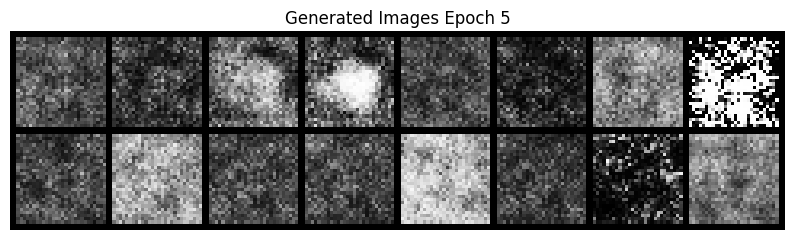

[Epoch 6/100] [Loss D: 0.9087] [Loss G: 1.9642]
[Epoch 7/100] [Loss D: 0.6811] [Loss G: 2.1289]
[Epoch 8/100] [Loss D: 0.7357] [Loss G: 1.6113]
[Epoch 9/100] [Loss D: 0.8898] [Loss G: 2.4602]
[Epoch 10/100] [Loss D: 1.0007] [Loss G: 2.0740]
--- Menghitung FID Score Manual pada Epoch 10 ---
>> Real-FID Score di Epoch 10: 126.9092



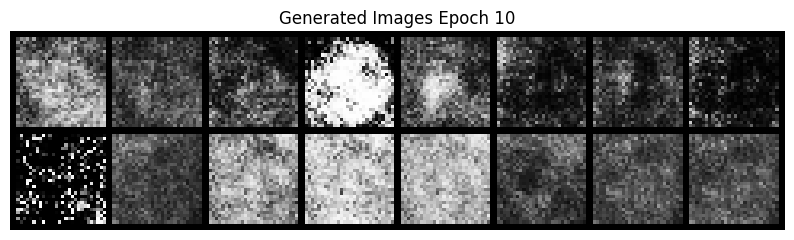

[Epoch 11/100] [Loss D: 0.9317] [Loss G: 1.9393]
[Epoch 12/100] [Loss D: 1.3205] [Loss G: 3.0709]
[Epoch 13/100] [Loss D: 0.8883] [Loss G: 2.0338]
[Epoch 14/100] [Loss D: 0.8155] [Loss G: 2.0313]
[Epoch 15/100] [Loss D: 0.9005] [Loss G: 1.9319]


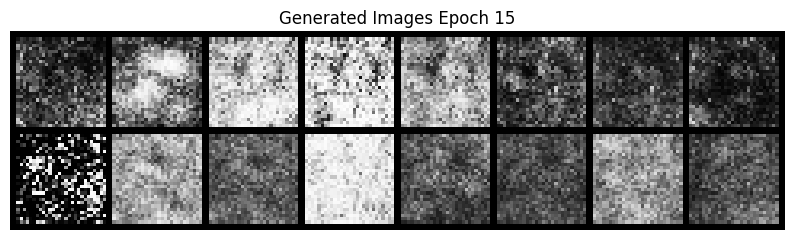

[Epoch 16/100] [Loss D: 0.6597] [Loss G: 1.8601]
[Epoch 17/100] [Loss D: 0.9402] [Loss G: 2.3756]
[Epoch 18/100] [Loss D: 0.8964] [Loss G: 2.2790]
[Epoch 19/100] [Loss D: 0.7951] [Loss G: 2.4407]
[Epoch 20/100] [Loss D: 0.8356] [Loss G: 2.3665]
--- Menghitung FID Score Manual pada Epoch 20 ---
>> Real-FID Score di Epoch 20: 145.3341



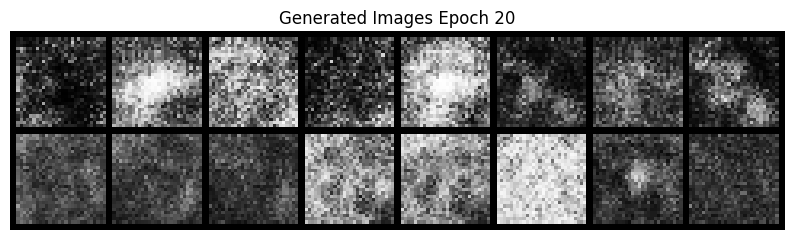

[Epoch 21/100] [Loss D: 0.6479] [Loss G: 2.1364]
[Epoch 22/100] [Loss D: 0.7391] [Loss G: 2.2756]
[Epoch 23/100] [Loss D: 0.5159] [Loss G: 1.8004]
[Epoch 24/100] [Loss D: 0.6519] [Loss G: 2.4361]
[Epoch 25/100] [Loss D: 0.7433] [Loss G: 2.2605]


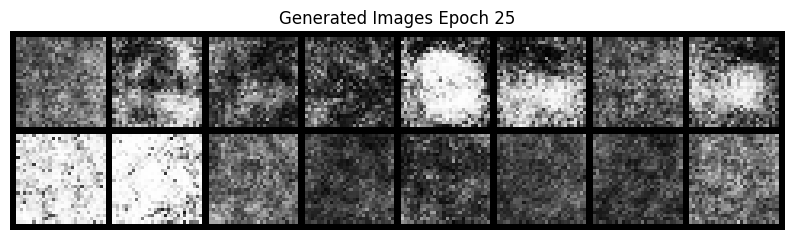

[Epoch 26/100] [Loss D: 0.9738] [Loss G: 2.2998]
[Epoch 27/100] [Loss D: 0.7260] [Loss G: 2.7053]
[Epoch 28/100] [Loss D: 0.6678] [Loss G: 2.2479]
[Epoch 29/100] [Loss D: 0.7747] [Loss G: 2.3006]
[Epoch 30/100] [Loss D: 0.8061] [Loss G: 2.4494]
--- Menghitung FID Score Manual pada Epoch 30 ---
>> Real-FID Score di Epoch 30: 136.4156



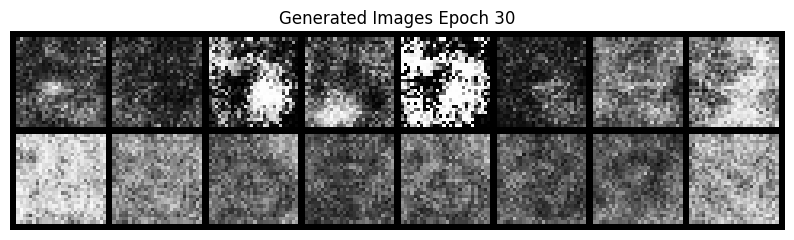

[Epoch 31/100] [Loss D: 0.5621] [Loss G: 2.5270]
[Epoch 32/100] [Loss D: 0.7517] [Loss G: 2.6545]
[Epoch 33/100] [Loss D: 0.8600] [Loss G: 3.0069]
[Epoch 34/100] [Loss D: 0.5520] [Loss G: 2.1969]
[Epoch 35/100] [Loss D: 0.6868] [Loss G: 2.6670]


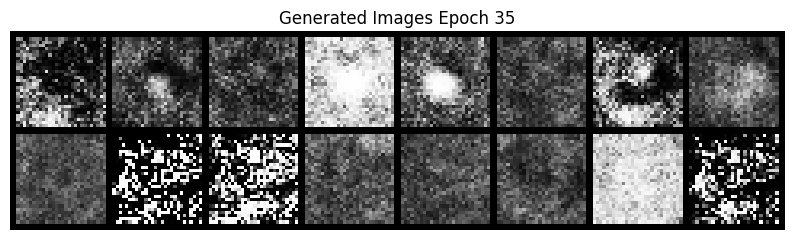

[Epoch 36/100] [Loss D: 0.9351] [Loss G: 2.4702]
[Epoch 37/100] [Loss D: 0.7602] [Loss G: 2.0944]
[Epoch 38/100] [Loss D: 0.6027] [Loss G: 2.1486]
[Epoch 39/100] [Loss D: 0.9790] [Loss G: 3.4203]
[Epoch 40/100] [Loss D: 0.7155] [Loss G: 2.2287]
--- Menghitung FID Score Manual pada Epoch 40 ---
>> Real-FID Score di Epoch 40: 133.6531



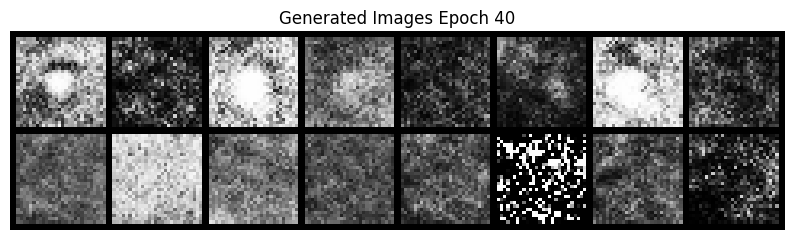

[Epoch 41/100] [Loss D: 0.7760] [Loss G: 2.0135]
[Epoch 42/100] [Loss D: 0.6806] [Loss G: 2.1503]
[Epoch 43/100] [Loss D: 0.7142] [Loss G: 2.3887]
[Epoch 44/100] [Loss D: 0.5303] [Loss G: 2.9981]
[Epoch 45/100] [Loss D: 0.4977] [Loss G: 2.7221]


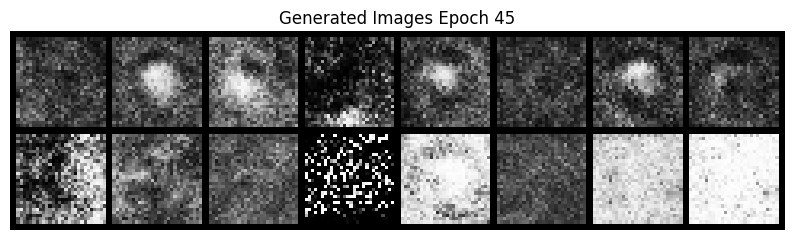

[Epoch 46/100] [Loss D: 0.6393] [Loss G: 2.1685]
[Epoch 47/100] [Loss D: 0.9893] [Loss G: 2.6396]
[Epoch 48/100] [Loss D: 0.6131] [Loss G: 2.4397]
[Epoch 49/100] [Loss D: 0.6877] [Loss G: 2.7212]
[Epoch 50/100] [Loss D: 0.5999] [Loss G: 2.8378]
--- Menghitung FID Score Manual pada Epoch 50 ---
>> Real-FID Score di Epoch 50: 135.4199



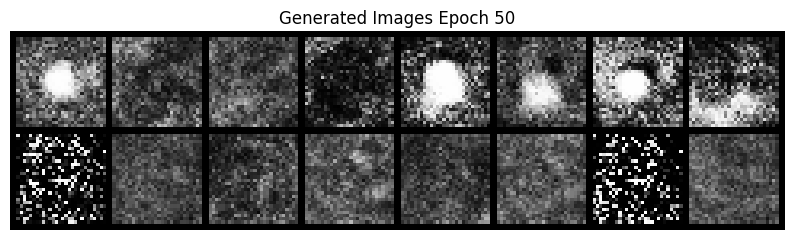

[Epoch 51/100] [Loss D: 0.5987] [Loss G: 2.4362]
[Epoch 52/100] [Loss D: 0.6164] [Loss G: 2.6958]
[Epoch 53/100] [Loss D: 0.6144] [Loss G: 2.3109]
[Epoch 54/100] [Loss D: 0.6769] [Loss G: 2.5777]
[Epoch 55/100] [Loss D: 0.6914] [Loss G: 3.2099]


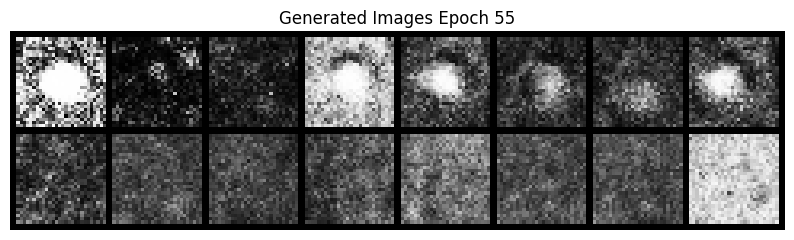

[Epoch 56/100] [Loss D: 0.4114] [Loss G: 2.7450]
[Epoch 57/100] [Loss D: 0.5364] [Loss G: 2.3716]
[Epoch 58/100] [Loss D: 0.5734] [Loss G: 2.6833]
[Epoch 59/100] [Loss D: 0.5065] [Loss G: 2.5955]
[Epoch 60/100] [Loss D: 0.3778] [Loss G: 2.7306]
--- Menghitung FID Score Manual pada Epoch 60 ---
>> Real-FID Score di Epoch 60: 137.2102



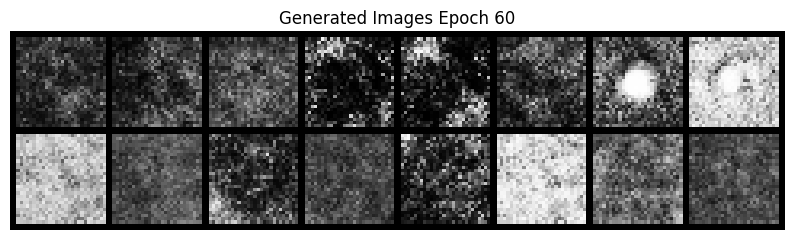

[Epoch 61/100] [Loss D: 0.5160] [Loss G: 2.4407]
[Epoch 62/100] [Loss D: 0.4998] [Loss G: 2.7225]
[Epoch 63/100] [Loss D: 0.6344] [Loss G: 1.9623]
[Epoch 64/100] [Loss D: 0.4268] [Loss G: 2.9558]
[Epoch 65/100] [Loss D: 0.4248] [Loss G: 2.8869]


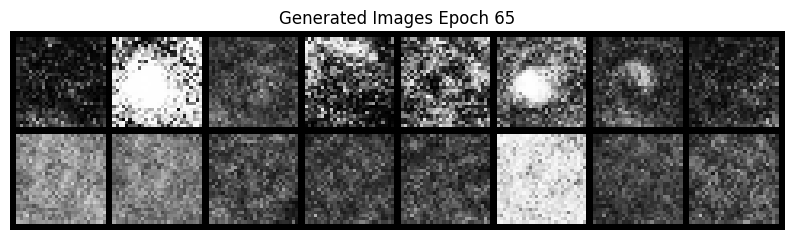

[Epoch 66/100] [Loss D: 0.5848] [Loss G: 3.0876]
[Epoch 67/100] [Loss D: 0.6673] [Loss G: 2.9994]
[Epoch 68/100] [Loss D: 0.5007] [Loss G: 2.6212]
[Epoch 69/100] [Loss D: 0.5454] [Loss G: 2.8812]
[Epoch 70/100] [Loss D: 1.4097] [Loss G: 4.7134]
--- Menghitung FID Score Manual pada Epoch 70 ---
>> Real-FID Score di Epoch 70: 133.0938



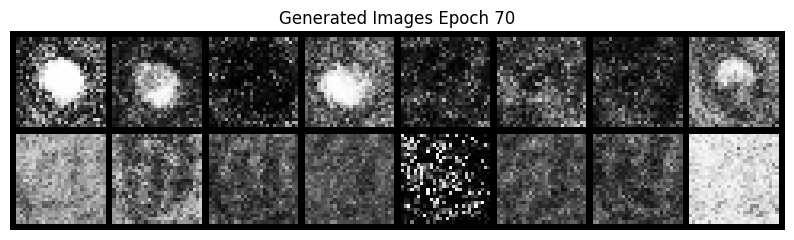

[Epoch 71/100] [Loss D: 0.5424] [Loss G: 2.8405]
[Epoch 72/100] [Loss D: 0.6619] [Loss G: 2.8442]
[Epoch 73/100] [Loss D: 0.3597] [Loss G: 2.9864]
[Epoch 74/100] [Loss D: 0.4546] [Loss G: 2.9846]
[Epoch 75/100] [Loss D: 0.5096] [Loss G: 3.7314]


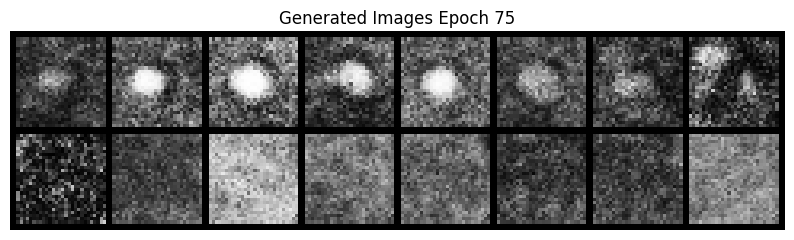

[Epoch 76/100] [Loss D: 0.6227] [Loss G: 2.2228]
[Epoch 77/100] [Loss D: 0.4187] [Loss G: 2.8489]
[Epoch 78/100] [Loss D: 0.4475] [Loss G: 2.9517]
[Epoch 79/100] [Loss D: 0.5763] [Loss G: 2.7453]
[Epoch 80/100] [Loss D: 0.4520] [Loss G: 3.1056]
--- Menghitung FID Score Manual pada Epoch 80 ---
>> Real-FID Score di Epoch 80: 140.0590



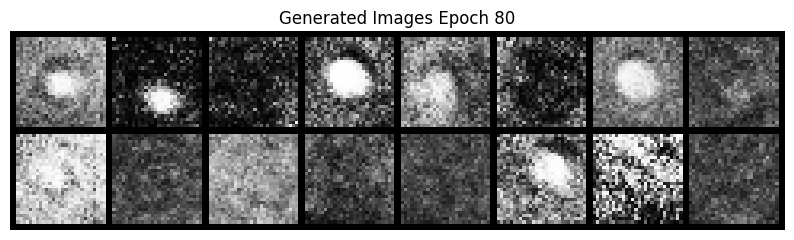

[Epoch 81/100] [Loss D: 0.3830] [Loss G: 3.5501]
[Epoch 82/100] [Loss D: 0.4559] [Loss G: 3.1410]
[Epoch 83/100] [Loss D: 0.4764] [Loss G: 2.9064]
[Epoch 84/100] [Loss D: 0.2835] [Loss G: 3.1743]
[Epoch 85/100] [Loss D: 0.4010] [Loss G: 3.4390]


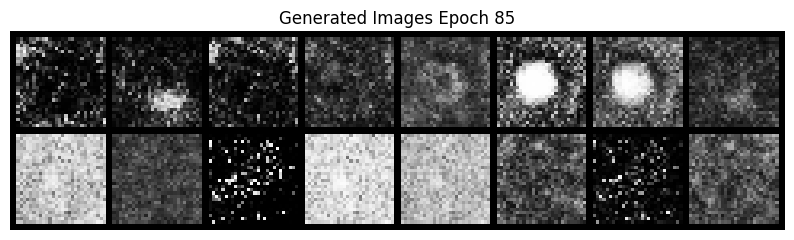

[Epoch 86/100] [Loss D: 0.4325] [Loss G: 3.0959]
[Epoch 87/100] [Loss D: 0.3201] [Loss G: 4.1374]
[Epoch 88/100] [Loss D: 0.5024] [Loss G: 3.7577]
[Epoch 89/100] [Loss D: 0.4071] [Loss G: 3.5343]
[Epoch 90/100] [Loss D: 0.2631] [Loss G: 3.6599]
--- Menghitung FID Score Manual pada Epoch 90 ---
>> Real-FID Score di Epoch 90: 145.4454



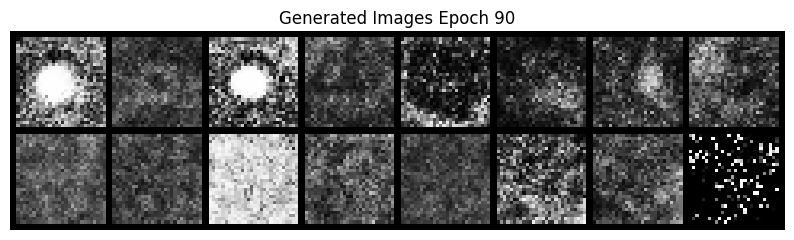

[Epoch 91/100] [Loss D: 0.2963] [Loss G: 3.3379]
[Epoch 92/100] [Loss D: 0.5304] [Loss G: 3.6948]
[Epoch 93/100] [Loss D: 0.2561] [Loss G: 3.1807]
[Epoch 94/100] [Loss D: 0.4220] [Loss G: 3.8863]
[Epoch 95/100] [Loss D: 0.4794] [Loss G: 3.0790]


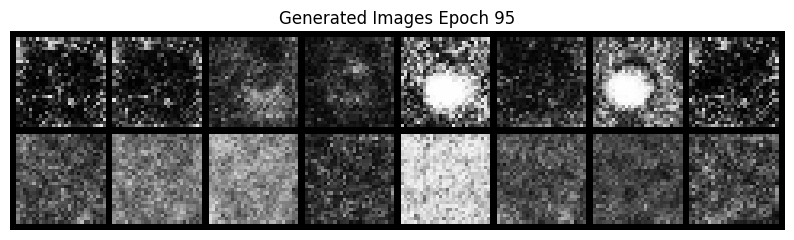

[Epoch 96/100] [Loss D: 0.2872] [Loss G: 3.6388]
[Epoch 97/100] [Loss D: 0.8588] [Loss G: 2.9833]
[Epoch 98/100] [Loss D: 0.1935] [Loss G: 3.7302]
[Epoch 99/100] [Loss D: 0.3097] [Loss G: 3.7151]
[Epoch 100/100] [Loss D: 0.3348] [Loss G: 3.6714]
--- Menghitung FID Score Manual pada Epoch 100 ---
>> Real-FID Score di Epoch 100: 151.7579



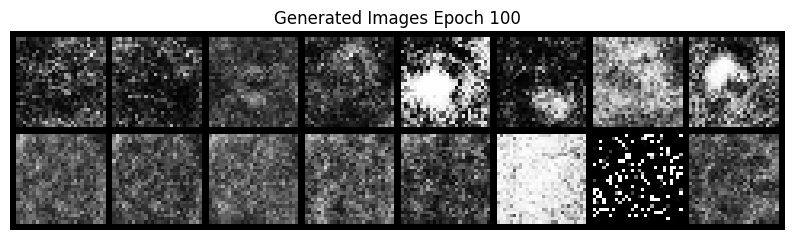

In [ ]:
import torchvision.utils as vutils

NUM_EPOCHS = 100
FID_INTERVAL = 10  # Hitung FID tiap 10x epoch
SAMPLE_INTERVAL = 5

losses_G = []
losses_D = []
fid_scores = []

print("Memulai Pelatihan CGAN dengan Evaluasi FID...")

for epoch in range(NUM_EPOCHS): # Training Loop
    generator.train()
    discriminator.train()

    for i, (real_imgs, labels) in enumerate(dataloader):
        batch_size = real_imgs.size(0)
        
        #Target labeling untuk diskriminator
        real_imgs = real_imgs.to(device)
        labels = labels.to(device)
        
        real_target = torch.ones(batch_size, 1).to(device) 
        fake_target = torch.zeros(batch_size, 1).to(device)

        # 1. Latih Discriminator
        optimizer_D.zero_grad()

        # 2. evaluasi gambar asli
        output_real = discriminator(real_imgs, labels)
        loss_D_real = criterion(output_real, real_target)

        # 3. Pembuatan Gambar Palsu & Evaluasi
        noise = torch.randn(batch_size, NOISE_DIM).to(device)
        fake_imgs = generator(noise, labels)

        output_fake = discriminator(fake_imgs.detach(), labels)
        loss_D_fake = criterion(output_fake, fake_target)

        # 4. Update Bobot Discriminator
        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        optimizer_D.step()

        # 5. Latih Generator (Unsaturated)
        optimizer_G.zero_grad()

        output_fake_for_G = discriminator(fake_imgs, labels)
        loss_G = criterion(output_fake_for_G, real_target)

        loss_G.backward()
        optimizer_G.step()

    #Catat skor loss
    losses_D.append(loss_D.item())
    losses_G.append(loss_G.item())

    print(f"[Epoch {epoch+1}/{NUM_EPOCHS}] [Loss D: {loss_D.item():.4f}] [Loss G: {loss_G.item():.4f}]")

    if (epoch + 1) % FID_INTERVAL == 0:
        generator.eval()

        all_real_features = []
        all_fake_features = []
        
        #FID Calculation
        print(f"--- Menghitung FID Score Manual pada Epoch {epoch+1} ---")
        with torch.no_grad():
            for real_batch_imgs, batch_labels in dataloader:
                batch_size = real_batch_imgs.size(0)
                real_batch_imgs = real_batch_imgs.to(device)
                batch_labels = batch_labels.to(device)

                # Generate gambar palsu
                z = torch.randn(batch_size, NOISE_DIM).to(device)
                fake_batch_imgs = generator(z, batch_labels)

                # Flatten gambar dari (B, 1, 28, 28) menjadi vektor (B, 784)
                real_flat = real_batch_imgs.view(batch_size, -1).cpu().numpy()
                fake_flat = fake_batch_imgs.view(batch_size, -1).cpu().numpy()

                all_real_features.append(real_flat)
                all_fake_features.append(fake_flat)

        # Gabungkan semua batch menjadi satu array besar
        all_real_features = np.concatenate(all_real_features, axis=0)
        all_fake_features = np.concatenate(all_fake_features, axis=0)

        # Hitung skor FID berdasarkan pixel distributions
        epoch_fid = calculate_numpy_fid(all_real_features, all_fake_features)
        fid_scores.append((epoch + 1, epoch_fid))
        print(f">> Real-FID Score di Epoch {epoch+1}: {epoch_fid:.4f}\n")

    # Cetak sampel gambar tiap 5 epoch
    if (epoch + 1) % SAMPLE_INTERVAL == 0:
        generator.eval()
        with torch.no_grad():
            sample_noise = torch.randn(16, NOISE_DIM).to(device)
            sample_labels = torch.cat([torch.zeros(8), torch.ones(8)]).long().to(device)
            gen_imgs = generator(sample_noise, sample_labels)
            gen_imgs = (gen_imgs + 1) / 2

            grid = vutils.make_grid(gen_imgs.cpu(), nrow=8, normalize=True)
            plt.figure(figsize=(10, 4))
            plt.imshow(grid.permute(1, 2, 0).numpy())
            plt.title(f"Generated Images Epoch {epoch+1}")
            plt.axis('off')
            plt.show()

#### B.6 Loss Plot

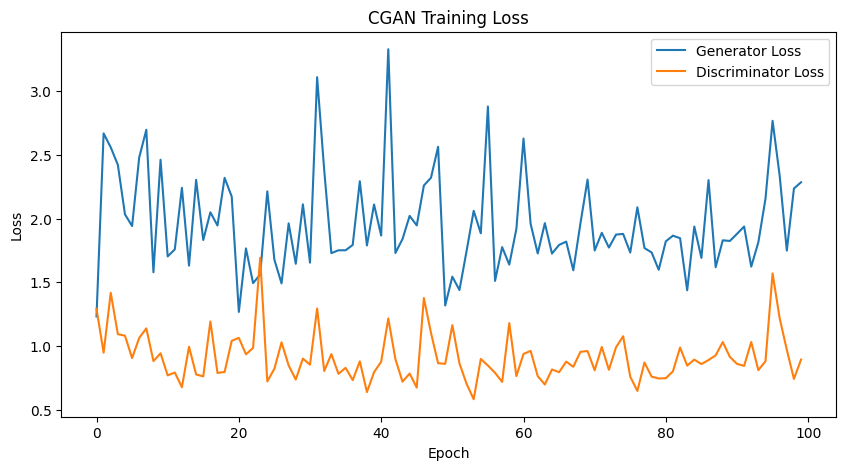

In [52]:
plt.figure(figsize=(10, 5))
plt.plot(losses_G, label="Generator Loss")
plt.plot(losses_D, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("CGAN Training Loss")
plt.show()

Grafik perkembangan loss antar generator dan diskriminator seiring berjalannya epoch menunjukan kedua kurva yang terus berosilasi sejak epoch awal hingga akhir dan batas selisih terlihat stabil. Tidak ada kurva yang meledak jauh ke atas atau anjlok menyentuh 0. Teknik unsaturated membantu kedua generator dan diskriminator untuk tidak mati di awal.

Kurva perbandingan loss yang sehat ditandai oleh tidak ada salah satu jaringan saraf dengan loss yang langsung merosot kebawah 0.1 atau lonjakan loss ke angka 5 atau 7.

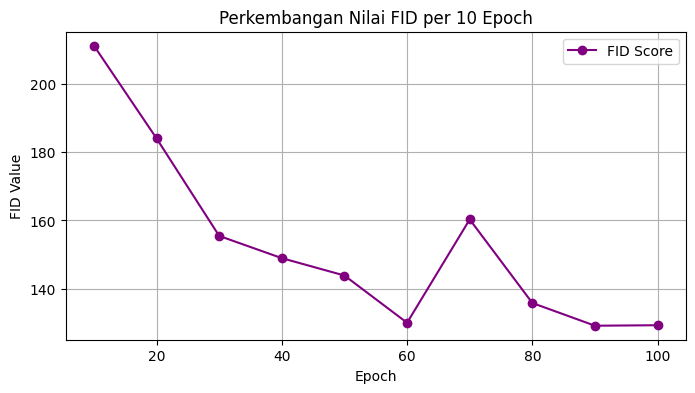

In [53]:
if fid_scores:
    epochs_fid, scores_fid = zip(*fid_scores)
    plt.figure(figsize=(8, 4))
    plt.plot(epochs_fid, scores_fid, marker='o', color='purple', label='FID Score')
    plt.xlabel("Epoch")
    plt.ylabel("FID Value")
    plt.title("Perkembangan Nilai FID per 10 Epoch")
    plt.grid(True)
    plt.legend()
    plt.show()

Perkembangan jaringan saraf cGAN menunjukan perkembangan yang baik dimana angka FID turun secara konsisten ke bawah dari epoch awal hingga epoch 60. Ini menunjukan kemiripan distribusi piksel gambar buatan model semakin mendekati dataset asli secara signifikan. 

Pada epoch 60 hingga 70, terjadi kenaikan FID yang lalu turun lagi ke All Time Low pada epoch akhir. Anomali ini merupakan ciri khas dari GAN ketika generator mencoba arah pemetaan baru yang digagalkan oleh diskriminator dan kemudian melakukan self-correction.

Di epoch ke 90-100, performa model FID mulai stagnan dan konstan yang menandakan model telah menyentuh titik konvergen optimal untuk arsitektur MLP baseline.

### C. Modify GAN Architecture

Solusi untuk menaikan FID ke ATL: upgrade cGAN menjadi cDCGAN

Dengan mengganti lapisan Linear menjadi lapisan Konvolusi. Konvolusi bekerja mendeteksi fitur lokal (tepi, sudut, bentuk lingkaran tangki, atau garis parkir) secara spasial.

Kita bisa memodifikasi Generator menggunakan nn.ConvTranspose2d (untuk upsampling) dan Discriminator menggunakan nn.Conv2d (untuk downsampling).

#### C.1.1 Modified Generator

In [ ]:
class ConditionalDCGenerator(nn.Module):
    def __init__(self, noise_dim, n_classes, img_size=28):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, 50)

        # Proyeksi awal gabungan noise + label_emb ke bentuk tensor
        self.init_layer = nn.Linear(noise_dim + 50, 256 * 7 * 7)

        self.conv_blocks = nn.Sequential(
            nn.BatchNorm2d(256), 
            # Blok 1: Dari 256 channel ke 128 channel
            nn.ConvTranspose2d(256, 128, kernel_size=4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),

            # Blok 2: Dari 128 channel langsung ke 1 channel (output gambar)
            nn.ConvTranspose2d(128, 1, kernel_size=4, stride=2, padding=1),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        c = self.label_emb(labels)
        x = torch.cat([noise, c], dim=1)
        x = self.init_layer(x)

        x = x.view(-1, 256, 7, 7)

        return self.conv_blocks(x)

Penyesuaian arsitektur DC-generator:
1.  Mengubah nn.Linear menjadi nn.ConvTranspose2d

2. Menggunakan struktur filter dari 32 -> 64 ke 256 -> 128 untuk proyeksi awal. Ini membuat model bisa membaca detail gambar lebih presisi

3. Menggunakan normalisasi nn.BatchNorm2d dengan menghitung statistik per batch data agar citra gambar dapat diidentifikasi antar objek vs background.

4. Menggunakan kernel_size = 4, stride = 2, padding =1 untuk mereduksi dimensi gambar secara bertahap dan menjadi esensi spasial gambar.

#### C.1.2 Modified Discriminator

In [ ]:
class ConditionalDCDiscriminator(nn.Module):
    def __init__(self, n_classes, img_size=28):
        super().__init__()
        self.label_emb = nn.Embedding(n_classes, 50)

        # Ekstraksi fitur spasial gambar lewat konvolusi
        self.conv_blocks = nn.Sequential(
            # Blok 1: Naikkan ke 64 filter
            nn.Conv2d(1, 64, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.1), 

            # Blok 2: Naikkan ke 128 filter
            nn.Conv2d(64, 128, kernel_size=4, stride=2, padding=1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Dropout(0.1)
        )

        self.fc = nn.Sequential(
            nn.Linear((128 * 7 * 7) + 50, 128),
            nn.LeakyReLU(0.2, inplace=True),
            nn.Linear(128, 1),
            nn.Sigmoid()
        )


    def forward(self, img, labels):
        feat = self.conv_blocks(img)
        feat_flat = feat.view(feat.size(0), -1)

        c = self.label_emb(labels)
        x = torch.cat([feat_flat, c], dim=1)
        return self.fc(x)

Penyesuaian arsitektur DC-diskriminator:
1. Ganti nn.linear -> nn.conv2dtranspose()

2. Mengganti ukuran filter dari 32 -> 64 menjadi 64 -> 128 agar ruang parameter lebih luas dalam mempelajari fitur spasial gambar

3. Menggunakan batchnorm2d 'tuk menghitung statistik per batch data dan menjadi citra gambar dan mempermudah perbandingan objek dengan background.

4. menggunakan kernel_size 4, stride 2, padding 1 untuk reduksi dimensi gambar bertahap dan menjadi kualitas gambaar yang dipelajari.

5. menggunakan dropout untuk mencegah model overfitting

In [ ]:
# Hyperparameters
NOISE_DIM = 100
N_CLASSES = 2 
IMG_SIZE = 28

# Inisialisasi
generator = ConditionalDCGenerator(noise_dim=NOISE_DIM, n_classes=N_CLASSES, img_size=IMG_SIZE).to(device)
discriminator = ConditionalDCDiscriminator(n_classes=N_CLASSES, img_size=IMG_SIZE).to(device)

print(generator)
print(discriminator)

ConditionalDCGenerator(
  (label_emb): Embedding(2, 50)
  (init_layer): Linear(in_features=150, out_features=12544, bias=True)
  (conv_blocks): Sequential(
    (0): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (1): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (3): LeakyReLU(negative_slope=0.2, inplace=True)
    (4): ConvTranspose2d(128, 1, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (5): Tanh()
  )
)
ConditionalDCDiscriminator(
  (label_emb): Embedding(2, 50)
  (conv_blocks): Sequential(
    (0): Conv2d(1, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (1): LeakyReLU(negative_slope=0.2, inplace=True)
    (2): Dropout(p=0.1, inplace=False)
    (3): Conv2d(64, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1))
    (4): LeakyReLU(negative_slope=0.2, inplace=True)
    (5): Dropout(p=0.1, inplace=Fal

#### C.2 Modified Optimizer

Dalam arsitektur baseline atau modifikasi awal, tugas Discriminator jauh lebih mudah (hanya membedakan gambar asli vs palsu) dibandingkan tugas Generator (membuat gambar realistis dari sebuah noise acak dari nol). 

Jika $LR$ keduanya dipasang sama besar ($0.0002$), Discriminator akan menjadi pintar terlalu cepat (overpowered). Begitu Discriminator terlalu dominan, dia akan langsung memberikan penalti nilai mendekati 0 untuk setiap gambar buatan Generator tanpa memberikan arah gradien yang jelas bagi Generator untuk memperbaiki diri.

Dengan menurunkan $LR_D$, kita sengaja "mengerem" kecepatan belajar Discriminator agar memberikan waktu bagi Generator untuk mengejar ketertinggalannya dalam memahami struktur spasial gambar (storage tank atau parking lot).

In [ ]:
import torch.optim as optim

criterion = nn.BCELoss()

LR_G = 0.0002
LR_D = 0.00001 #turunkan dari 0.0002
BETA1 = 0.5
BETA2 = 0.999

# 2. Optimizer Terpisah
optimizer_G = optim.Adam(generator.parameters(), lr=LR_G, betas=(BETA1, BETA2))
optimizer_D = optim.Adam(discriminator.parameters(), lr=LR_D, betas=(BETA1, BETA2))

#### C.3 Training Loop

Perubahan di training loop:
1. Epoch: 400

2. Checkpoint model dengan FID terendah

3. smoothing real_target menjadi 0.95 agar discriminator menjadi lebih cerdas dan rem agresifitas diskriminator 

Memulai Pelatihan CGAN dengan Evaluasi FID...
[Epoch 1/400] [Loss D: 0.5541] [Loss G: 2.4675]
[Epoch 2/400] [Loss D: 0.3583] [Loss G: 3.0473]
[Epoch 3/400] [Loss D: 0.4798] [Loss G: 1.9415]
[Epoch 4/400] [Loss D: 0.5386] [Loss G: 2.9480]
[Epoch 5/400] [Loss D: 0.4325] [Loss G: 1.9021]


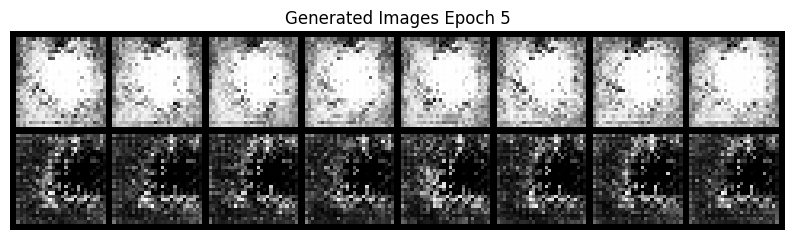

[Epoch 6/400] [Loss D: 0.3877] [Loss G: 2.5680]
[Epoch 7/400] [Loss D: 0.4371] [Loss G: 3.3471]
[Epoch 8/400] [Loss D: 0.4648] [Loss G: 1.9147]
[Epoch 9/400] [Loss D: 0.3594] [Loss G: 3.0458]
[Epoch 10/400] [Loss D: 0.6538] [Loss G: 2.2144]
--- Menghitung FID Score Manual pada Epoch 10 ---
>> Real-FID Score di Epoch 10: 261.0913

--> [SAVE] FID membaik! Menyimpan model terbaik ke best_cgan_model.pth...




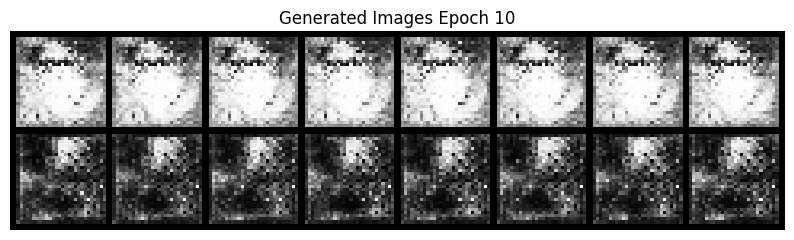

[Epoch 11/400] [Loss D: 0.6338] [Loss G: 3.3157]
[Epoch 12/400] [Loss D: 1.1255] [Loss G: 1.6141]
[Epoch 13/400] [Loss D: 0.9124] [Loss G: 1.5129]
[Epoch 14/400] [Loss D: 1.6378] [Loss G: 1.3892]
[Epoch 15/400] [Loss D: 1.2708] [Loss G: 1.4553]


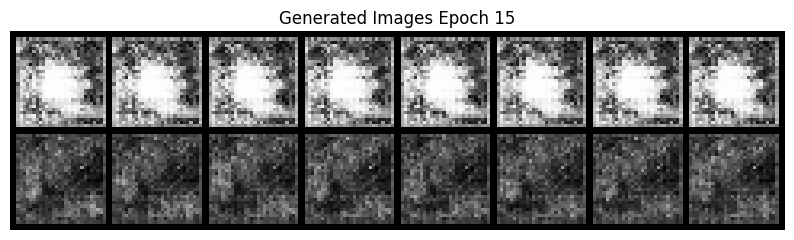

[Epoch 16/400] [Loss D: 0.8519] [Loss G: 1.4826]
[Epoch 17/400] [Loss D: 0.9385] [Loss G: 1.6551]
[Epoch 18/400] [Loss D: 0.7641] [Loss G: 1.7703]
[Epoch 19/400] [Loss D: 1.1020] [Loss G: 1.9500]
[Epoch 20/400] [Loss D: 0.7613] [Loss G: 2.0409]
--- Menghitung FID Score Manual pada Epoch 20 ---
>> Real-FID Score di Epoch 20: 281.5949





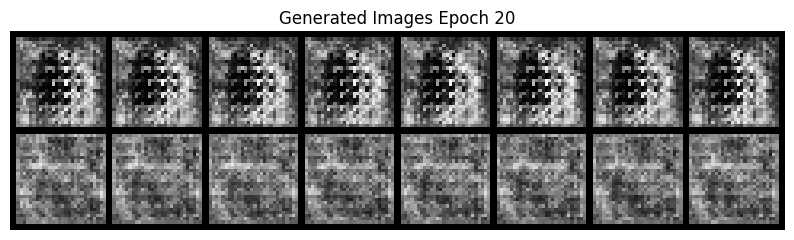

[Epoch 21/400] [Loss D: 0.8771] [Loss G: 1.7269]
[Epoch 22/400] [Loss D: 0.8469] [Loss G: 2.1027]
[Epoch 23/400] [Loss D: 0.7751] [Loss G: 3.3972]
[Epoch 24/400] [Loss D: 0.8875] [Loss G: 1.4918]
[Epoch 25/400] [Loss D: 1.2741] [Loss G: 3.2892]


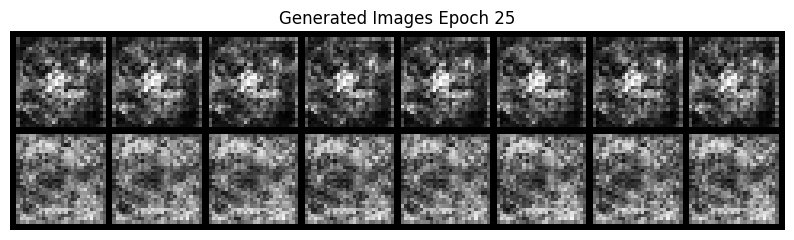

[Epoch 26/400] [Loss D: 1.3765] [Loss G: 1.8272]
[Epoch 27/400] [Loss D: 0.7193] [Loss G: 2.0417]
[Epoch 28/400] [Loss D: 0.6436] [Loss G: 2.5069]
[Epoch 29/400] [Loss D: 0.5354] [Loss G: 3.0723]
[Epoch 30/400] [Loss D: 0.7079] [Loss G: 2.2608]
--- Menghitung FID Score Manual pada Epoch 30 ---
>> Real-FID Score di Epoch 30: 212.4323

--> [SAVE] FID membaik! Menyimpan model terbaik ke best_cgan_model.pth...




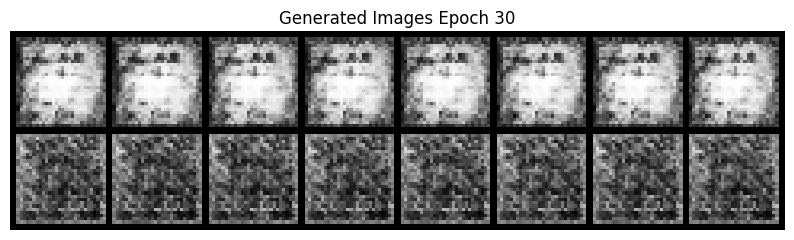

[Epoch 31/400] [Loss D: 0.5107] [Loss G: 2.4208]
[Epoch 32/400] [Loss D: 0.6710] [Loss G: 2.5696]
[Epoch 33/400] [Loss D: 0.7472] [Loss G: 2.4176]
[Epoch 34/400] [Loss D: 0.7046] [Loss G: 2.3467]
[Epoch 35/400] [Loss D: 0.8798] [Loss G: 1.9009]


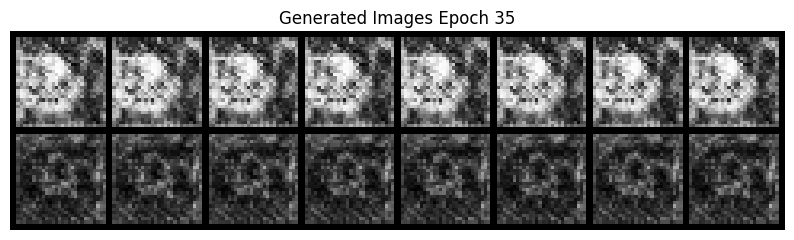

[Epoch 36/400] [Loss D: 0.5699] [Loss G: 2.0748]
[Epoch 37/400] [Loss D: 0.5384] [Loss G: 4.4207]
[Epoch 38/400] [Loss D: 0.8011] [Loss G: 2.1094]
[Epoch 39/400] [Loss D: 0.6250] [Loss G: 2.6361]
[Epoch 40/400] [Loss D: 0.6385] [Loss G: 2.3504]
--- Menghitung FID Score Manual pada Epoch 40 ---
>> Real-FID Score di Epoch 40: 226.9198





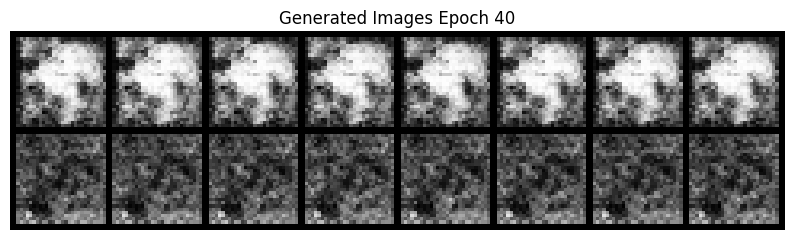

[Epoch 41/400] [Loss D: 0.5872] [Loss G: 2.4418]
[Epoch 42/400] [Loss D: 0.6010] [Loss G: 2.8349]
[Epoch 43/400] [Loss D: 0.7260] [Loss G: 2.4072]
[Epoch 44/400] [Loss D: 0.6452] [Loss G: 2.7819]
[Epoch 45/400] [Loss D: 0.6033] [Loss G: 2.2998]


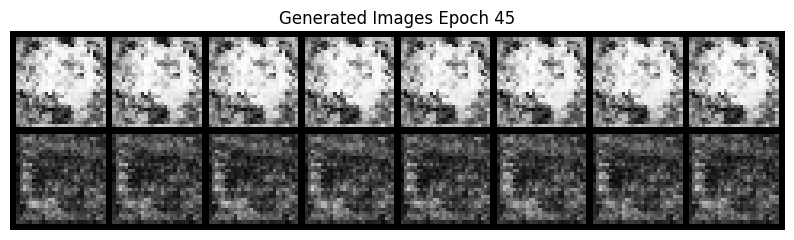

[Epoch 46/400] [Loss D: 0.5592] [Loss G: 2.9948]
[Epoch 47/400] [Loss D: 0.6943] [Loss G: 2.6168]
[Epoch 48/400] [Loss D: 0.5130] [Loss G: 2.7662]
[Epoch 49/400] [Loss D: 0.6436] [Loss G: 2.6440]
[Epoch 50/400] [Loss D: 0.5239] [Loss G: 3.2008]
--- Menghitung FID Score Manual pada Epoch 50 ---
>> Real-FID Score di Epoch 50: 267.4009





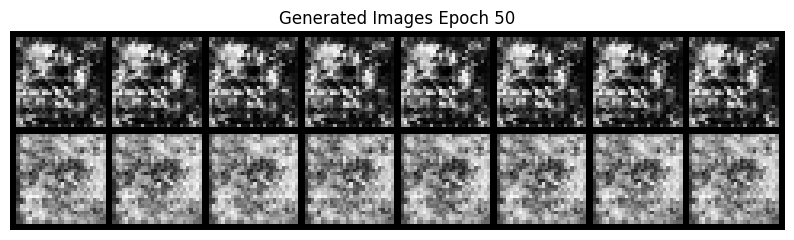

[Epoch 51/400] [Loss D: 0.4982] [Loss G: 2.8981]
[Epoch 52/400] [Loss D: 0.4660] [Loss G: 3.3021]
[Epoch 53/400] [Loss D: 0.5272] [Loss G: 2.9474]
[Epoch 54/400] [Loss D: 0.8129] [Loss G: 2.3648]
[Epoch 55/400] [Loss D: 0.5140] [Loss G: 3.1228]


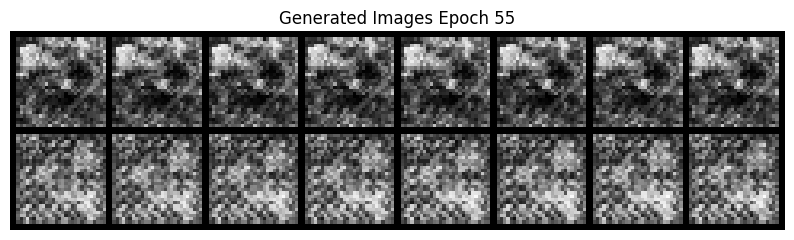

[Epoch 56/400] [Loss D: 0.5499] [Loss G: 2.2559]
[Epoch 57/400] [Loss D: 0.5534] [Loss G: 2.5217]
[Epoch 58/400] [Loss D: 0.4786] [Loss G: 3.0747]
[Epoch 59/400] [Loss D: 0.6525] [Loss G: 2.3545]
[Epoch 60/400] [Loss D: 0.5812] [Loss G: 2.4277]
--- Menghitung FID Score Manual pada Epoch 60 ---
>> Real-FID Score di Epoch 60: 245.1772





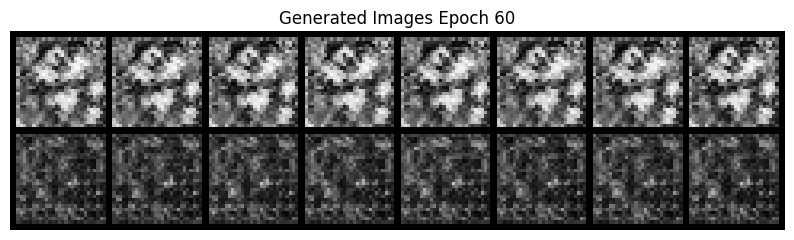

[Epoch 61/400] [Loss D: 0.4516] [Loss G: 3.2041]
[Epoch 62/400] [Loss D: 0.4264] [Loss G: 3.5598]
[Epoch 63/400] [Loss D: 0.4971] [Loss G: 2.6704]
[Epoch 64/400] [Loss D: 0.4936] [Loss G: 2.6724]
[Epoch 65/400] [Loss D: 0.6839] [Loss G: 3.6979]


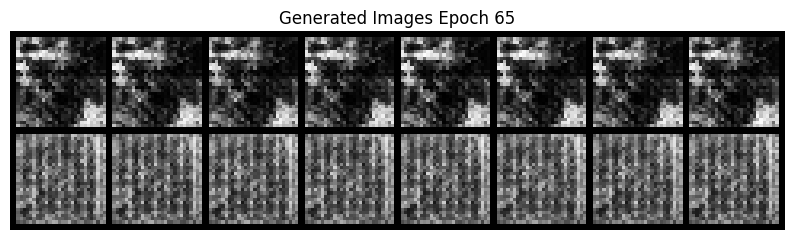

[Epoch 66/400] [Loss D: 0.7444] [Loss G: 3.4156]
[Epoch 67/400] [Loss D: 0.7804] [Loss G: 1.7155]
[Epoch 68/400] [Loss D: 0.7013] [Loss G: 2.9061]
[Epoch 69/400] [Loss D: 0.4724] [Loss G: 2.5895]
[Epoch 70/400] [Loss D: 0.4940] [Loss G: 3.1875]
--- Menghitung FID Score Manual pada Epoch 70 ---
>> Real-FID Score di Epoch 70: 238.5954





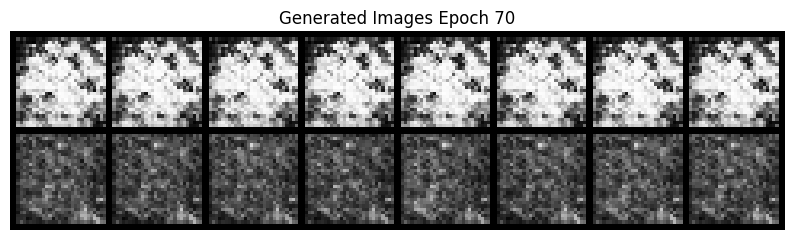

[Epoch 71/400] [Loss D: 0.4348] [Loss G: 3.1943]
[Epoch 72/400] [Loss D: 0.4501] [Loss G: 4.5243]
[Epoch 73/400] [Loss D: 0.5625] [Loss G: 2.6190]
[Epoch 74/400] [Loss D: 0.7105] [Loss G: 2.7422]
[Epoch 75/400] [Loss D: 0.5405] [Loss G: 3.1253]


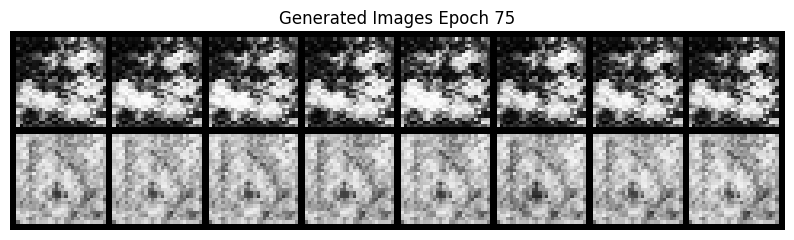

[Epoch 76/400] [Loss D: 0.6299] [Loss G: 2.2227]
[Epoch 77/400] [Loss D: 0.6421] [Loss G: 3.8922]
[Epoch 78/400] [Loss D: 0.5014] [Loss G: 3.0945]
[Epoch 79/400] [Loss D: 0.4915] [Loss G: 3.0217]
[Epoch 80/400] [Loss D: 0.6164] [Loss G: 2.6187]
--- Menghitung FID Score Manual pada Epoch 80 ---
>> Real-FID Score di Epoch 80: 247.9098





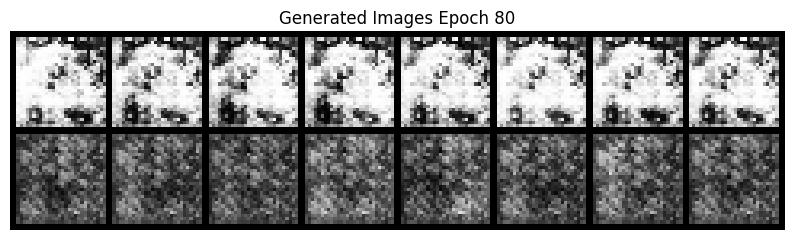

[Epoch 81/400] [Loss D: 0.5756] [Loss G: 2.5999]
[Epoch 82/400] [Loss D: 0.7085] [Loss G: 2.5072]
[Epoch 83/400] [Loss D: 0.6067] [Loss G: 2.5664]
[Epoch 84/400] [Loss D: 0.6533] [Loss G: 3.2636]
[Epoch 85/400] [Loss D: 0.5161] [Loss G: 2.9938]


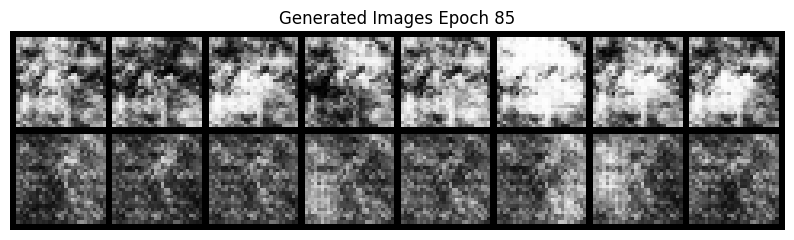

[Epoch 86/400] [Loss D: 0.6766] [Loss G: 2.0488]
[Epoch 87/400] [Loss D: 0.8892] [Loss G: 2.2429]
[Epoch 88/400] [Loss D: 0.7022] [Loss G: 2.2964]
[Epoch 89/400] [Loss D: 0.7761] [Loss G: 2.5993]
[Epoch 90/400] [Loss D: 1.0885] [Loss G: 3.4439]
--- Menghitung FID Score Manual pada Epoch 90 ---
>> Real-FID Score di Epoch 90: 181.4297

--> [SAVE] FID membaik! Menyimpan model terbaik ke best_cgan_model.pth...




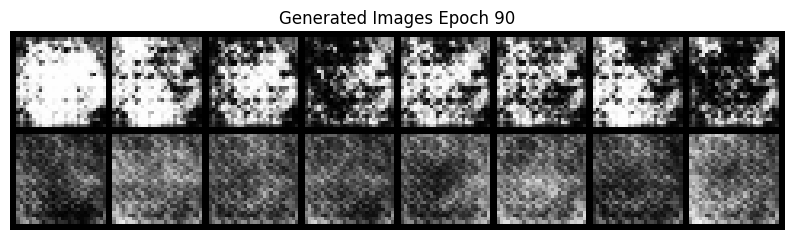

[Epoch 91/400] [Loss D: 0.8960] [Loss G: 2.0925]
[Epoch 92/400] [Loss D: 0.8118] [Loss G: 2.2266]
[Epoch 93/400] [Loss D: 0.7538] [Loss G: 2.1122]
[Epoch 94/400] [Loss D: 0.7609] [Loss G: 2.0137]
[Epoch 95/400] [Loss D: 0.6440] [Loss G: 2.6100]


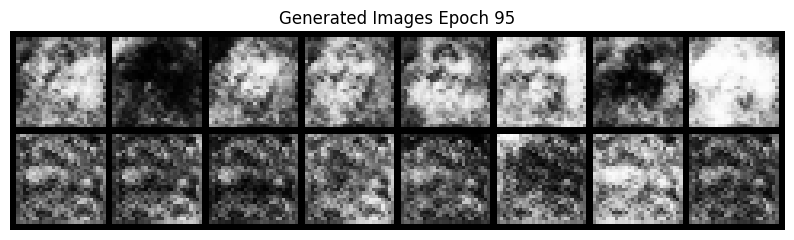

[Epoch 96/400] [Loss D: 0.8034] [Loss G: 2.0594]
[Epoch 97/400] [Loss D: 0.7084] [Loss G: 2.2477]
[Epoch 98/400] [Loss D: 0.6401] [Loss G: 2.9060]
[Epoch 99/400] [Loss D: 0.6624] [Loss G: 2.4799]
[Epoch 100/400] [Loss D: 0.8168] [Loss G: 1.8666]
--- Menghitung FID Score Manual pada Epoch 100 ---
>> Real-FID Score di Epoch 100: 177.9193

--> [SAVE] FID membaik! Menyimpan model terbaik ke best_cgan_model.pth...




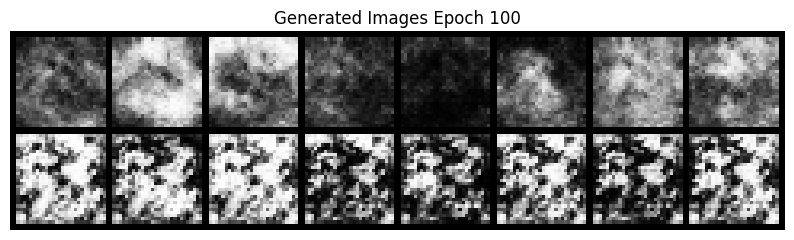

[Epoch 101/400] [Loss D: 0.5200] [Loss G: 3.3867]
[Epoch 102/400] [Loss D: 0.6380] [Loss G: 2.8479]
[Epoch 103/400] [Loss D: 0.5797] [Loss G: 2.5213]
[Epoch 104/400] [Loss D: 0.5959] [Loss G: 2.0419]
[Epoch 105/400] [Loss D: 0.6527] [Loss G: 2.3301]


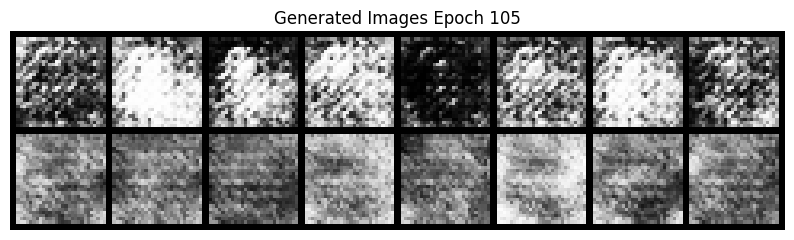

[Epoch 106/400] [Loss D: 0.8113] [Loss G: 2.7144]
[Epoch 107/400] [Loss D: 0.7574] [Loss G: 2.2347]
[Epoch 108/400] [Loss D: 0.5706] [Loss G: 2.5479]
[Epoch 109/400] [Loss D: 0.8252] [Loss G: 1.9465]
[Epoch 110/400] [Loss D: 0.6865] [Loss G: 2.6448]
--- Menghitung FID Score Manual pada Epoch 110 ---
>> Real-FID Score di Epoch 110: 118.3089

--> [SAVE] FID membaik! Menyimpan model terbaik ke best_cgan_model.pth...




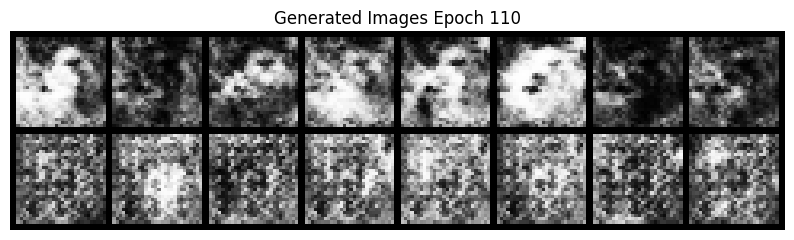

[Epoch 111/400] [Loss D: 0.6462] [Loss G: 2.4157]
[Epoch 112/400] [Loss D: 0.8609] [Loss G: 1.7766]
[Epoch 113/400] [Loss D: 0.7390] [Loss G: 2.3084]
[Epoch 114/400] [Loss D: 0.7020] [Loss G: 2.3730]
[Epoch 115/400] [Loss D: 0.5907] [Loss G: 3.0600]


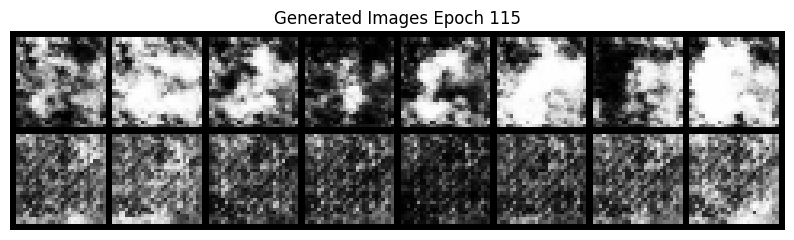

[Epoch 116/400] [Loss D: 0.7089] [Loss G: 1.9286]
[Epoch 117/400] [Loss D: 0.6122] [Loss G: 2.2415]
[Epoch 118/400] [Loss D: 0.6513] [Loss G: 3.1097]
[Epoch 119/400] [Loss D: 0.6652] [Loss G: 2.1291]
[Epoch 120/400] [Loss D: 0.8799] [Loss G: 2.5501]
--- Menghitung FID Score Manual pada Epoch 120 ---
>> Real-FID Score di Epoch 120: 104.2996

--> [SAVE] FID membaik! Menyimpan model terbaik ke best_cgan_model.pth...




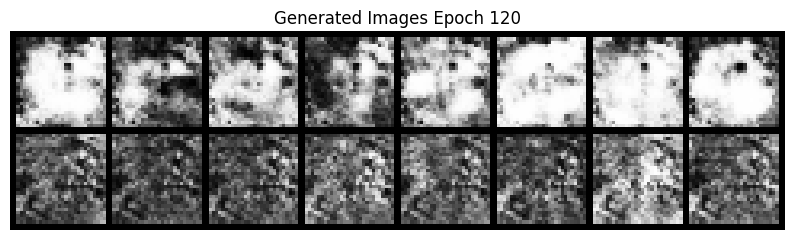

[Epoch 121/400] [Loss D: 0.7883] [Loss G: 2.3790]
[Epoch 122/400] [Loss D: 0.7792] [Loss G: 2.0534]
[Epoch 123/400] [Loss D: 0.8248] [Loss G: 2.4429]
[Epoch 124/400] [Loss D: 0.6260] [Loss G: 2.5645]
[Epoch 125/400] [Loss D: 0.6813] [Loss G: 2.4165]


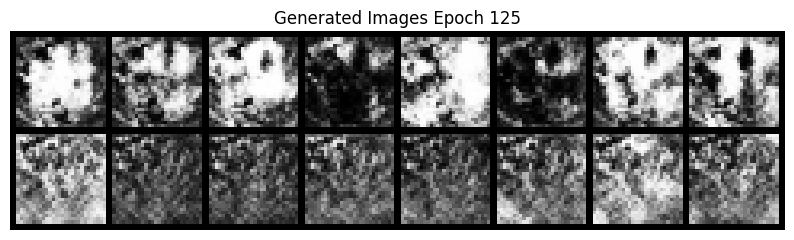

[Epoch 126/400] [Loss D: 0.6474] [Loss G: 3.1034]
[Epoch 127/400] [Loss D: 0.7367] [Loss G: 2.4606]
[Epoch 128/400] [Loss D: 0.5497] [Loss G: 2.5805]
[Epoch 129/400] [Loss D: 0.6710] [Loss G: 2.7930]
[Epoch 130/400] [Loss D: 0.6109] [Loss G: 2.6974]
--- Menghitung FID Score Manual pada Epoch 130 ---
>> Real-FID Score di Epoch 130: 97.1288

--> [SAVE] FID membaik! Menyimpan model terbaik ke best_cgan_model.pth...




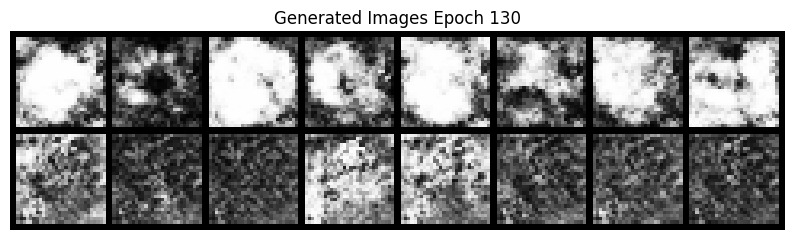

[Epoch 131/400] [Loss D: 0.7383] [Loss G: 2.3657]
[Epoch 132/400] [Loss D: 0.8620] [Loss G: 2.2272]
[Epoch 133/400] [Loss D: 0.8169] [Loss G: 2.4418]
[Epoch 134/400] [Loss D: 0.6161] [Loss G: 2.4452]
[Epoch 135/400] [Loss D: 0.7598] [Loss G: 2.2508]


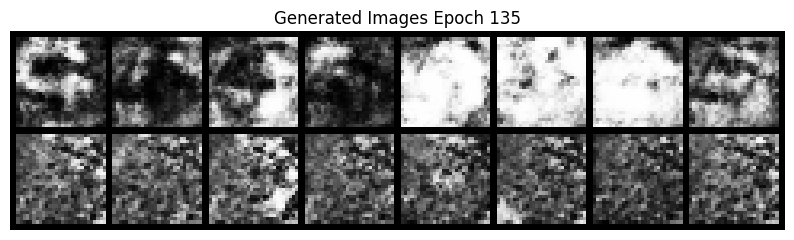

[Epoch 136/400] [Loss D: 0.6303] [Loss G: 2.6276]
[Epoch 137/400] [Loss D: 0.7773] [Loss G: 2.0848]
[Epoch 138/400] [Loss D: 0.6277] [Loss G: 2.5549]
[Epoch 139/400] [Loss D: 0.9570] [Loss G: 2.2258]
[Epoch 140/400] [Loss D: 0.8941] [Loss G: 2.3629]
--- Menghitung FID Score Manual pada Epoch 140 ---
>> Real-FID Score di Epoch 140: 105.2688





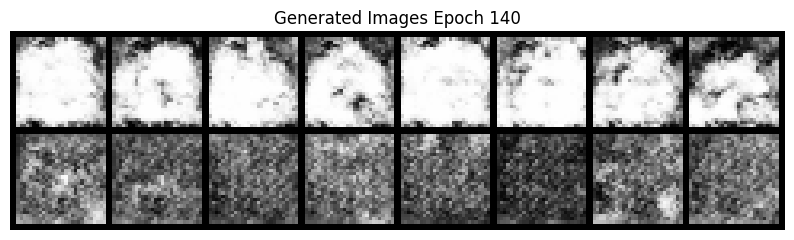

[Epoch 141/400] [Loss D: 0.7335] [Loss G: 2.1832]
[Epoch 142/400] [Loss D: 0.7619] [Loss G: 2.3180]
[Epoch 143/400] [Loss D: 0.6753] [Loss G: 2.2659]
[Epoch 144/400] [Loss D: 0.7404] [Loss G: 2.6098]
[Epoch 145/400] [Loss D: 0.7358] [Loss G: 2.0093]


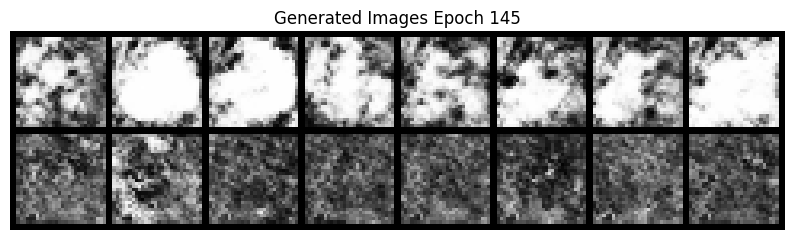

[Epoch 146/400] [Loss D: 0.6976] [Loss G: 2.3568]
[Epoch 147/400] [Loss D: 0.6157] [Loss G: 2.0140]
[Epoch 148/400] [Loss D: 0.8319] [Loss G: 2.2000]
[Epoch 149/400] [Loss D: 0.7068] [Loss G: 2.1128]
[Epoch 150/400] [Loss D: 0.7278] [Loss G: 2.2815]
--- Menghitung FID Score Manual pada Epoch 150 ---
>> Real-FID Score di Epoch 150: 100.8754





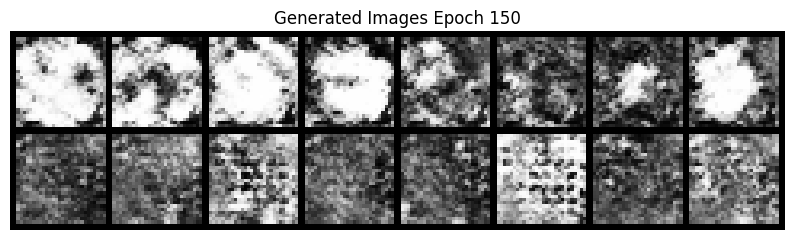

[Epoch 151/400] [Loss D: 0.8040] [Loss G: 2.2164]
[Epoch 152/400] [Loss D: 0.6198] [Loss G: 2.0033]
[Epoch 153/400] [Loss D: 0.6851] [Loss G: 2.5842]
[Epoch 154/400] [Loss D: 0.8954] [Loss G: 1.9722]
[Epoch 155/400] [Loss D: 0.8480] [Loss G: 1.8381]


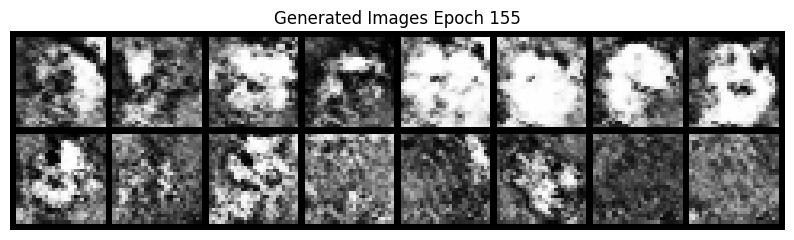

[Epoch 156/400] [Loss D: 0.7709] [Loss G: 2.1195]
[Epoch 157/400] [Loss D: 0.7567] [Loss G: 2.1367]
[Epoch 158/400] [Loss D: 0.6854] [Loss G: 2.5227]
[Epoch 159/400] [Loss D: 0.8843] [Loss G: 1.7574]
[Epoch 160/400] [Loss D: 0.7303] [Loss G: 2.2839]
--- Menghitung FID Score Manual pada Epoch 160 ---
>> Real-FID Score di Epoch 160: 76.9762

--> [SAVE] FID membaik! Menyimpan model terbaik ke best_cgan_model.pth...




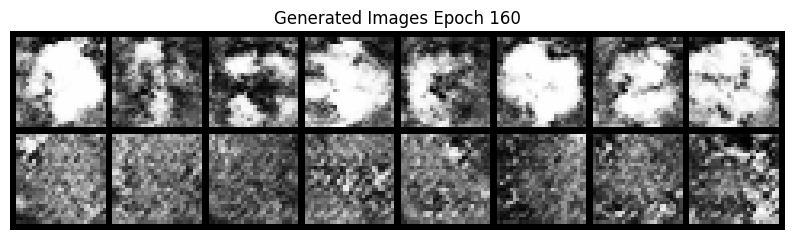

[Epoch 161/400] [Loss D: 0.8398] [Loss G: 3.0552]
[Epoch 162/400] [Loss D: 0.8068] [Loss G: 2.2315]
[Epoch 163/400] [Loss D: 0.8313] [Loss G: 2.3606]
[Epoch 164/400] [Loss D: 0.8202] [Loss G: 2.3582]
[Epoch 165/400] [Loss D: 0.7199] [Loss G: 2.0646]


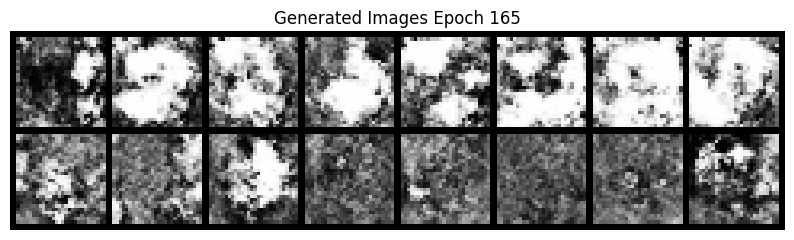

[Epoch 166/400] [Loss D: 0.7860] [Loss G: 2.2538]
[Epoch 167/400] [Loss D: 0.7212] [Loss G: 1.8720]
[Epoch 168/400] [Loss D: 0.8178] [Loss G: 1.9702]
[Epoch 169/400] [Loss D: 0.7978] [Loss G: 1.8850]
[Epoch 170/400] [Loss D: 0.8244] [Loss G: 2.4441]
--- Menghitung FID Score Manual pada Epoch 170 ---
>> Real-FID Score di Epoch 170: 67.7589

--> [SAVE] FID membaik! Menyimpan model terbaik ke best_cgan_model.pth...




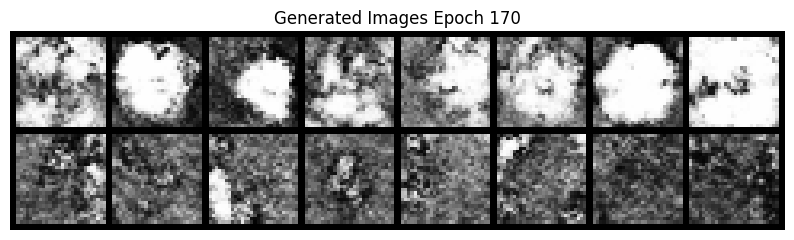

[Epoch 171/400] [Loss D: 0.7968] [Loss G: 1.9372]
[Epoch 172/400] [Loss D: 0.8217] [Loss G: 2.1873]
[Epoch 173/400] [Loss D: 0.8471] [Loss G: 2.2141]
[Epoch 174/400] [Loss D: 0.8420] [Loss G: 1.7791]
[Epoch 175/400] [Loss D: 0.9162] [Loss G: 1.8169]


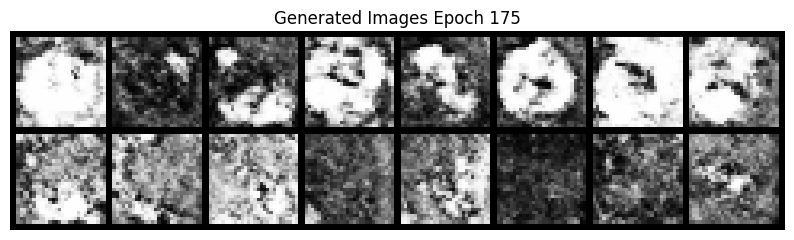

[Epoch 176/400] [Loss D: 0.8627] [Loss G: 1.8400]
[Epoch 177/400] [Loss D: 0.6906] [Loss G: 2.3002]
[Epoch 178/400] [Loss D: 0.8085] [Loss G: 2.1328]
[Epoch 179/400] [Loss D: 0.9558] [Loss G: 1.6470]
[Epoch 180/400] [Loss D: 0.7681] [Loss G: 2.1310]
--- Menghitung FID Score Manual pada Epoch 180 ---
>> Real-FID Score di Epoch 180: 59.5733

--> [SAVE] FID membaik! Menyimpan model terbaik ke best_cgan_model.pth...




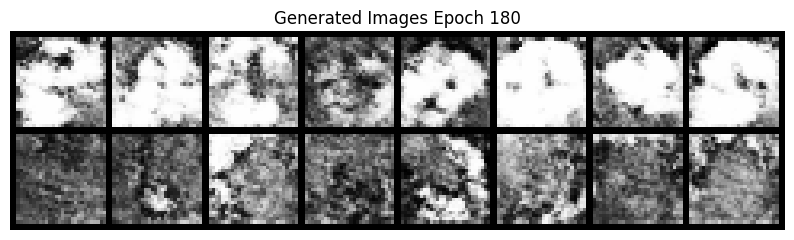

[Epoch 181/400] [Loss D: 0.7754] [Loss G: 1.9081]
[Epoch 182/400] [Loss D: 0.7799] [Loss G: 1.8973]
[Epoch 183/400] [Loss D: 0.7296] [Loss G: 2.2143]
[Epoch 184/400] [Loss D: 1.0074] [Loss G: 1.3794]
[Epoch 185/400] [Loss D: 0.8197] [Loss G: 2.0139]


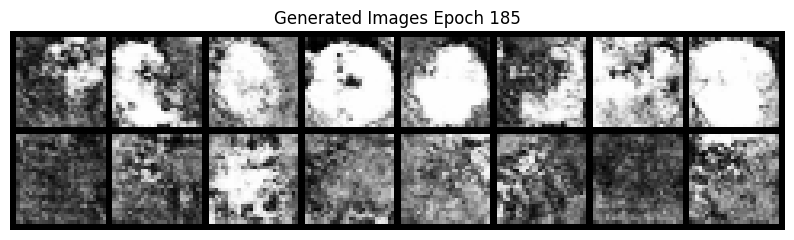

[Epoch 186/400] [Loss D: 0.6610] [Loss G: 2.4896]
[Epoch 187/400] [Loss D: 0.8774] [Loss G: 1.9713]
[Epoch 188/400] [Loss D: 0.8420] [Loss G: 1.8943]
[Epoch 189/400] [Loss D: 0.7946] [Loss G: 1.7526]
[Epoch 190/400] [Loss D: 0.7184] [Loss G: 1.6362]
--- Menghitung FID Score Manual pada Epoch 190 ---
>> Real-FID Score di Epoch 190: 52.6032

--> [SAVE] FID membaik! Menyimpan model terbaik ke best_cgan_model.pth...




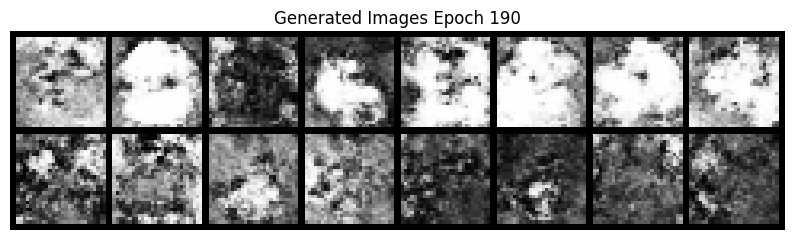

[Epoch 191/400] [Loss D: 0.8473] [Loss G: 1.7657]
[Epoch 192/400] [Loss D: 0.7824] [Loss G: 1.8632]
[Epoch 193/400] [Loss D: 0.8424] [Loss G: 2.7256]
[Epoch 194/400] [Loss D: 0.8207] [Loss G: 1.8368]
[Epoch 195/400] [Loss D: 0.7381] [Loss G: 1.8635]


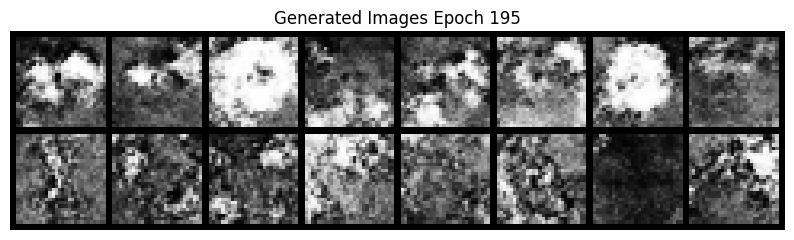

[Epoch 196/400] [Loss D: 0.7272] [Loss G: 2.1898]
[Epoch 197/400] [Loss D: 0.7153] [Loss G: 2.4490]
[Epoch 198/400] [Loss D: 0.8839] [Loss G: 1.8029]
[Epoch 199/400] [Loss D: 0.7516] [Loss G: 1.8871]
[Epoch 200/400] [Loss D: 0.6989] [Loss G: 1.8576]
--- Menghitung FID Score Manual pada Epoch 200 ---
>> Real-FID Score di Epoch 200: 53.5679





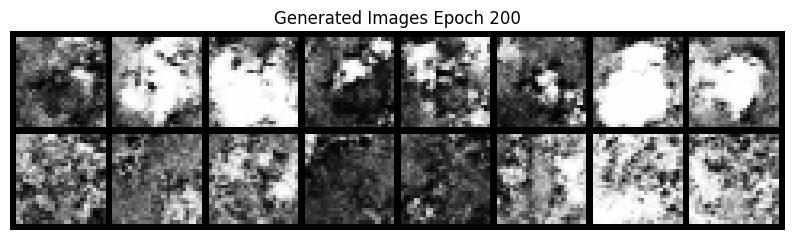

[Epoch 201/400] [Loss D: 0.7277] [Loss G: 3.1300]
[Epoch 202/400] [Loss D: 0.6676] [Loss G: 3.5494]
[Epoch 203/400] [Loss D: 0.5666] [Loss G: 2.9056]
[Epoch 204/400] [Loss D: 0.5611] [Loss G: 2.6324]
[Epoch 205/400] [Loss D: 0.6090] [Loss G: 2.8929]


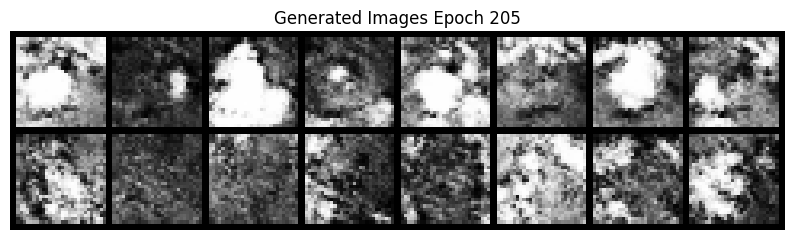

[Epoch 206/400] [Loss D: 0.6296] [Loss G: 1.9827]
[Epoch 207/400] [Loss D: 0.6074] [Loss G: 2.7716]
[Epoch 208/400] [Loss D: 0.8062] [Loss G: 2.4208]
[Epoch 209/400] [Loss D: 0.8708] [Loss G: 2.9923]
[Epoch 210/400] [Loss D: 0.8923] [Loss G: 1.7592]
--- Menghitung FID Score Manual pada Epoch 210 ---
>> Real-FID Score di Epoch 210: 44.9900

--> [SAVE] FID membaik! Menyimpan model terbaik ke best_cgan_model.pth...




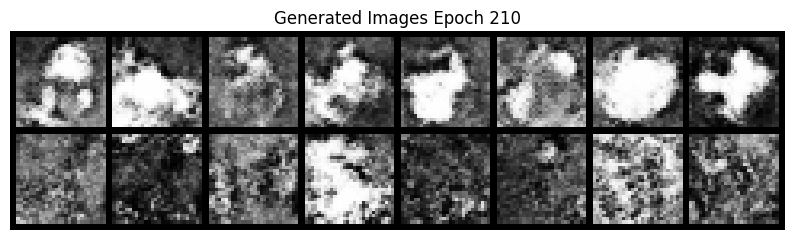

[Epoch 211/400] [Loss D: 0.6894] [Loss G: 2.1032]
[Epoch 212/400] [Loss D: 0.6358] [Loss G: 2.3136]
[Epoch 213/400] [Loss D: 0.7071] [Loss G: 2.0612]
[Epoch 214/400] [Loss D: 0.7633] [Loss G: 2.4398]
[Epoch 215/400] [Loss D: 0.5671] [Loss G: 2.4235]


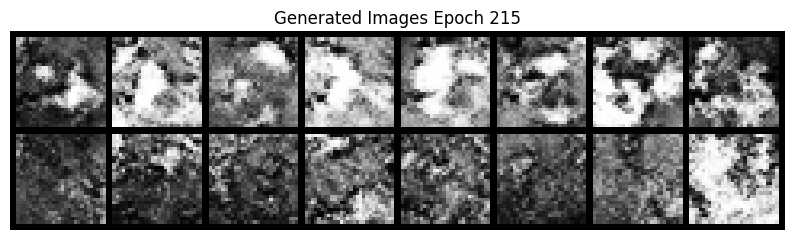

[Epoch 216/400] [Loss D: 0.6857] [Loss G: 1.7245]
[Epoch 217/400] [Loss D: 0.6841] [Loss G: 1.9568]
[Epoch 218/400] [Loss D: 0.4941] [Loss G: 2.4760]
[Epoch 219/400] [Loss D: 0.7012] [Loss G: 2.1095]
[Epoch 220/400] [Loss D: 0.5696] [Loss G: 2.2298]
--- Menghitung FID Score Manual pada Epoch 220 ---
>> Real-FID Score di Epoch 220: 42.0508

--> [SAVE] FID membaik! Menyimpan model terbaik ke best_cgan_model.pth...




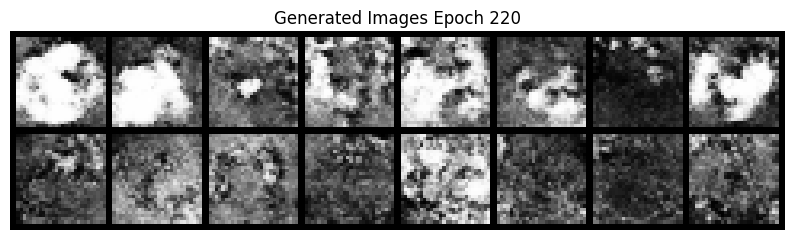

[Epoch 221/400] [Loss D: 0.6607] [Loss G: 2.8153]
[Epoch 222/400] [Loss D: 0.5315] [Loss G: 2.2455]
[Epoch 223/400] [Loss D: 0.7240] [Loss G: 3.0067]
[Epoch 224/400] [Loss D: 0.7072] [Loss G: 2.6686]
[Epoch 225/400] [Loss D: 0.7259] [Loss G: 2.2566]


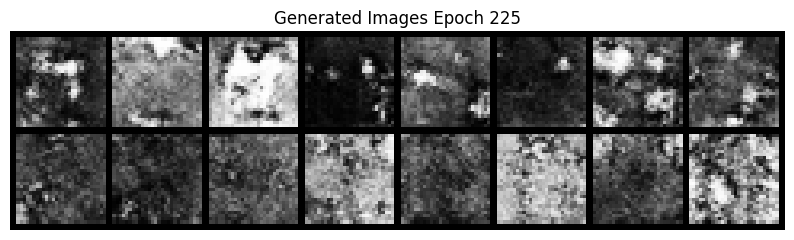

[Epoch 226/400] [Loss D: 0.7321] [Loss G: 3.3563]
[Epoch 227/400] [Loss D: 0.5574] [Loss G: 2.5275]
[Epoch 228/400] [Loss D: 0.7138] [Loss G: 2.2789]
[Epoch 229/400] [Loss D: 0.7753] [Loss G: 2.3363]
[Epoch 230/400] [Loss D: 0.6671] [Loss G: 2.0921]
--- Menghitung FID Score Manual pada Epoch 230 ---
>> Real-FID Score di Epoch 230: 48.2469





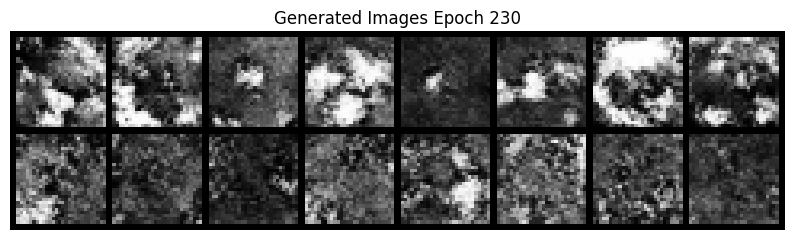

[Epoch 231/400] [Loss D: 0.6406] [Loss G: 1.8120]
[Epoch 232/400] [Loss D: 0.6072] [Loss G: 2.7841]
[Epoch 233/400] [Loss D: 0.7978] [Loss G: 2.0725]
[Epoch 234/400] [Loss D: 0.6180] [Loss G: 2.3149]
[Epoch 235/400] [Loss D: 0.6657] [Loss G: 2.2389]


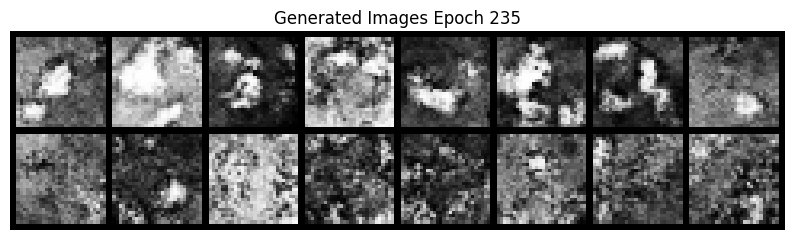

[Epoch 236/400] [Loss D: 0.6657] [Loss G: 2.8209]
[Epoch 237/400] [Loss D: 0.5883] [Loss G: 2.4734]
[Epoch 238/400] [Loss D: 0.6644] [Loss G: 2.1884]
[Epoch 239/400] [Loss D: 0.6260] [Loss G: 2.7890]
[Epoch 240/400] [Loss D: 0.6017] [Loss G: 2.1966]
--- Menghitung FID Score Manual pada Epoch 240 ---
>> Real-FID Score di Epoch 240: 50.0147





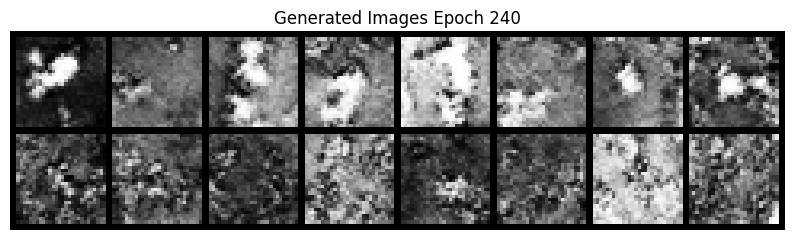

[Epoch 241/400] [Loss D: 0.5563] [Loss G: 2.9370]
[Epoch 242/400] [Loss D: 0.6135] [Loss G: 2.7245]
[Epoch 243/400] [Loss D: 0.5784] [Loss G: 2.8818]
[Epoch 244/400] [Loss D: 0.6953] [Loss G: 2.7041]
[Epoch 245/400] [Loss D: 0.5197] [Loss G: 2.5535]


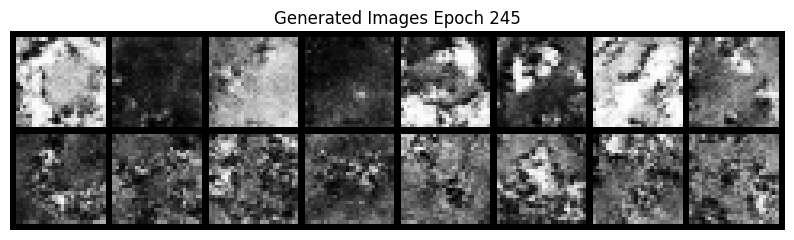

[Epoch 246/400] [Loss D: 0.7006] [Loss G: 2.8450]
[Epoch 247/400] [Loss D: 0.6930] [Loss G: 2.1423]
[Epoch 248/400] [Loss D: 0.6623] [Loss G: 2.5113]
[Epoch 249/400] [Loss D: 0.6780] [Loss G: 2.0660]
[Epoch 250/400] [Loss D: 0.7489] [Loss G: 1.9156]
--- Menghitung FID Score Manual pada Epoch 250 ---
>> Real-FID Score di Epoch 250: 57.4576





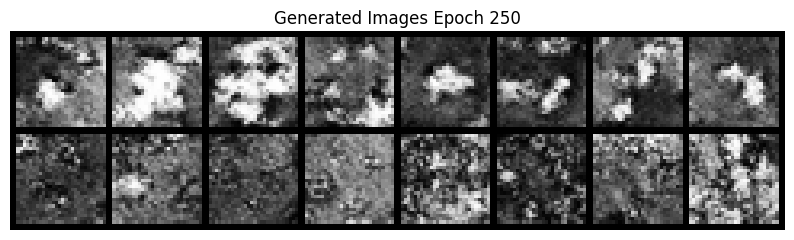

[Epoch 251/400] [Loss D: 0.6174] [Loss G: 2.7020]
[Epoch 252/400] [Loss D: 0.5930] [Loss G: 2.1641]
[Epoch 253/400] [Loss D: 0.6635] [Loss G: 2.1711]
[Epoch 254/400] [Loss D: 0.7723] [Loss G: 2.5851]
[Epoch 255/400] [Loss D: 0.7382] [Loss G: 2.4686]


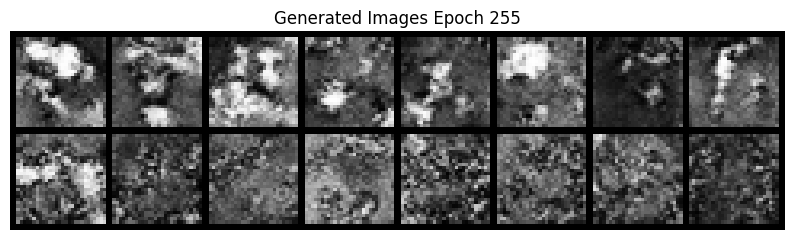

[Epoch 256/400] [Loss D: 0.6562] [Loss G: 2.8227]
[Epoch 257/400] [Loss D: 0.6995] [Loss G: 2.0719]
[Epoch 258/400] [Loss D: 0.6361] [Loss G: 2.4972]
[Epoch 259/400] [Loss D: 0.6205] [Loss G: 2.7966]
[Epoch 260/400] [Loss D: 0.5790] [Loss G: 2.0216]
--- Menghitung FID Score Manual pada Epoch 260 ---
>> Real-FID Score di Epoch 260: 73.4949





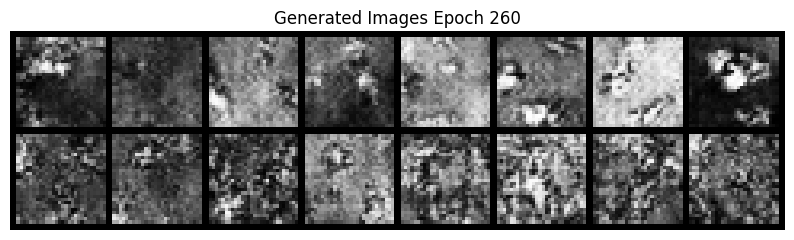

[Epoch 261/400] [Loss D: 0.7471] [Loss G: 2.0718]
[Epoch 262/400] [Loss D: 0.5867] [Loss G: 1.9437]
[Epoch 263/400] [Loss D: 0.5569] [Loss G: 3.0970]
[Epoch 264/400] [Loss D: 0.6977] [Loss G: 2.1012]
[Epoch 265/400] [Loss D: 0.6538] [Loss G: 2.2008]


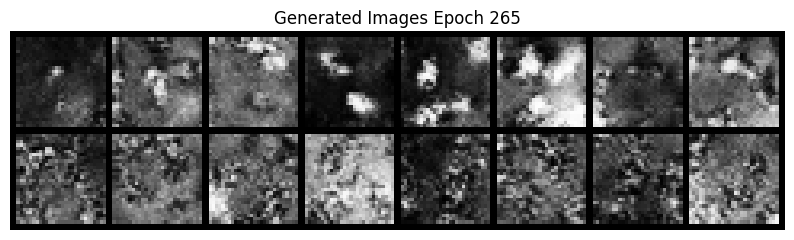

[Epoch 266/400] [Loss D: 0.7072] [Loss G: 2.0575]
[Epoch 267/400] [Loss D: 0.6172] [Loss G: 2.0001]
[Epoch 268/400] [Loss D: 0.5786] [Loss G: 2.0541]
[Epoch 269/400] [Loss D: 0.5859] [Loss G: 2.2953]
[Epoch 270/400] [Loss D: 0.6666] [Loss G: 2.7465]
--- Menghitung FID Score Manual pada Epoch 270 ---
>> Real-FID Score di Epoch 270: 78.8442





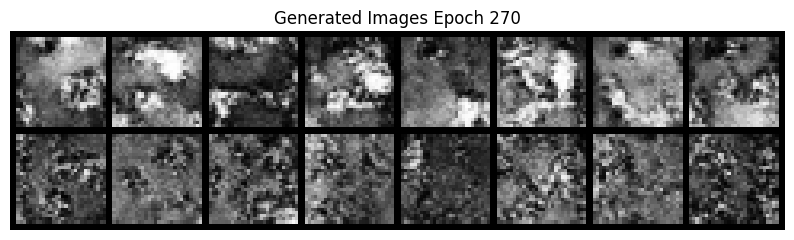

[Epoch 271/400] [Loss D: 0.7644] [Loss G: 1.9287]
[Epoch 272/400] [Loss D: 0.5492] [Loss G: 2.3916]
[Epoch 273/400] [Loss D: 0.5982] [Loss G: 2.4356]
[Epoch 274/400] [Loss D: 0.5387] [Loss G: 2.6578]
[Epoch 275/400] [Loss D: 0.6011] [Loss G: 2.3231]


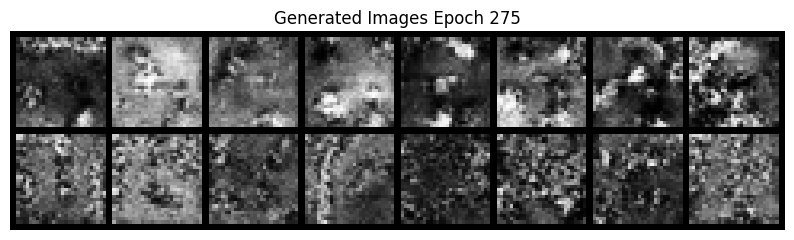

[Epoch 276/400] [Loss D: 0.6270] [Loss G: 2.9515]
[Epoch 277/400] [Loss D: 0.6510] [Loss G: 2.4250]
[Epoch 278/400] [Loss D: 0.6763] [Loss G: 2.4756]
[Epoch 279/400] [Loss D: 0.6648] [Loss G: 2.1423]
[Epoch 280/400] [Loss D: 0.6285] [Loss G: 2.3385]
--- Menghitung FID Score Manual pada Epoch 280 ---
>> Real-FID Score di Epoch 280: 94.9120





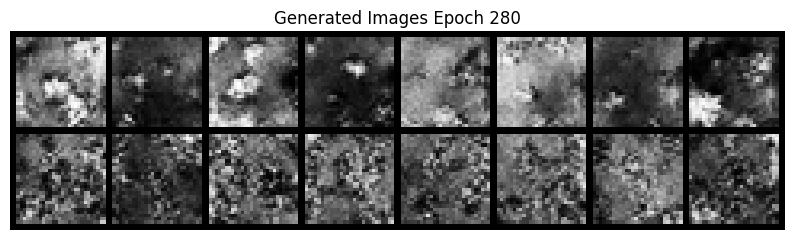

[Epoch 281/400] [Loss D: 0.7085] [Loss G: 2.3487]
[Epoch 282/400] [Loss D: 0.6052] [Loss G: 2.2945]
[Epoch 283/400] [Loss D: 0.6074] [Loss G: 2.4757]
[Epoch 284/400] [Loss D: 0.6345] [Loss G: 2.3279]
[Epoch 285/400] [Loss D: 0.5565] [Loss G: 2.6017]


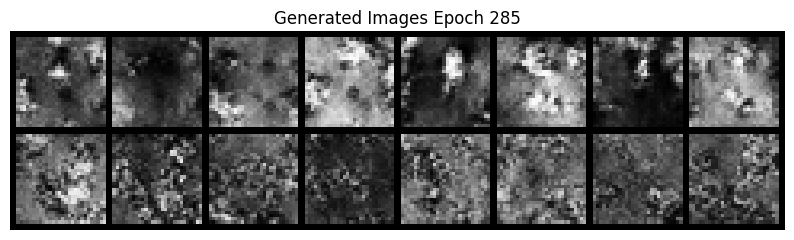

[Epoch 286/400] [Loss D: 0.6569] [Loss G: 2.6674]
[Epoch 287/400] [Loss D: 0.5226] [Loss G: 2.6493]
[Epoch 288/400] [Loss D: 0.5725] [Loss G: 2.6937]
[Epoch 289/400] [Loss D: 0.5595] [Loss G: 2.2691]
[Epoch 290/400] [Loss D: 0.6800] [Loss G: 1.8053]
--- Menghitung FID Score Manual pada Epoch 290 ---
>> Real-FID Score di Epoch 290: 112.2175





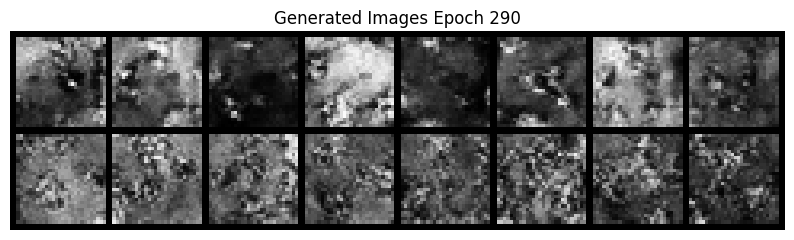

[Epoch 291/400] [Loss D: 0.5875] [Loss G: 2.6446]
[Epoch 292/400] [Loss D: 0.6366] [Loss G: 2.0528]
[Epoch 293/400] [Loss D: 0.6684] [Loss G: 2.2283]
[Epoch 294/400] [Loss D: 0.6080] [Loss G: 2.3003]
[Epoch 295/400] [Loss D: 0.4817] [Loss G: 2.5804]


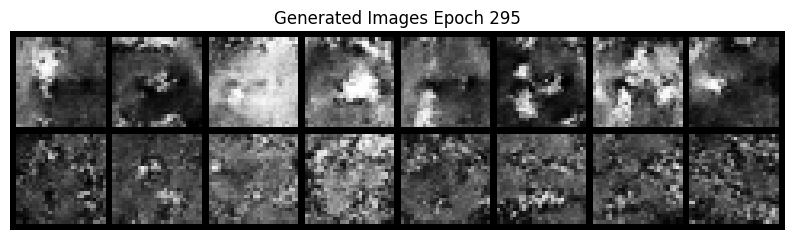

[Epoch 296/400] [Loss D: 0.5574] [Loss G: 2.6138]
[Epoch 297/400] [Loss D: 0.5597] [Loss G: 2.4090]
[Epoch 298/400] [Loss D: 0.6586] [Loss G: 2.1557]
[Epoch 299/400] [Loss D: 0.5760] [Loss G: 2.7185]
[Epoch 300/400] [Loss D: 0.6303] [Loss G: 2.5579]
--- Menghitung FID Score Manual pada Epoch 300 ---
>> Real-FID Score di Epoch 300: 93.3162





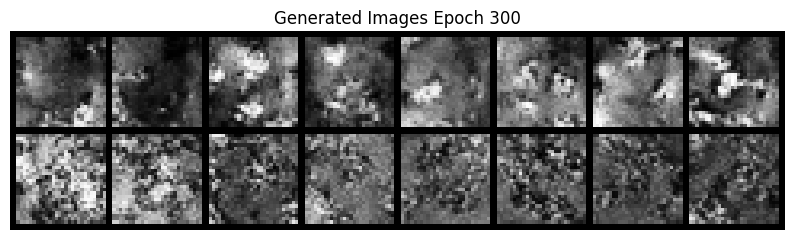

[Epoch 301/400] [Loss D: 0.4910] [Loss G: 2.6783]
[Epoch 302/400] [Loss D: 0.4944] [Loss G: 2.4630]
[Epoch 303/400] [Loss D: 0.5770] [Loss G: 2.4364]
[Epoch 304/400] [Loss D: 0.4743] [Loss G: 3.0856]
[Epoch 305/400] [Loss D: 0.5107] [Loss G: 2.6294]


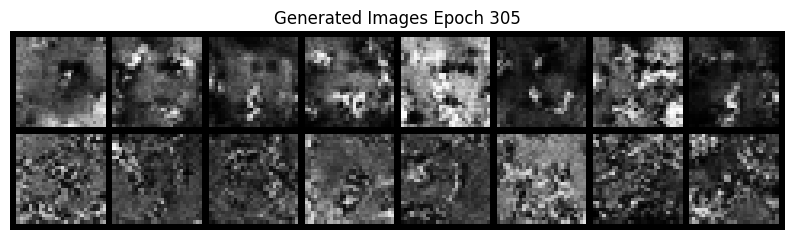

[Epoch 306/400] [Loss D: 0.4163] [Loss G: 2.9053]
[Epoch 307/400] [Loss D: 0.4505] [Loss G: 2.9579]
[Epoch 308/400] [Loss D: 0.4817] [Loss G: 2.4941]
[Epoch 309/400] [Loss D: 0.4924] [Loss G: 2.8884]
[Epoch 310/400] [Loss D: 0.5315] [Loss G: 2.5143]
--- Menghitung FID Score Manual pada Epoch 310 ---
>> Real-FID Score di Epoch 310: 107.5225





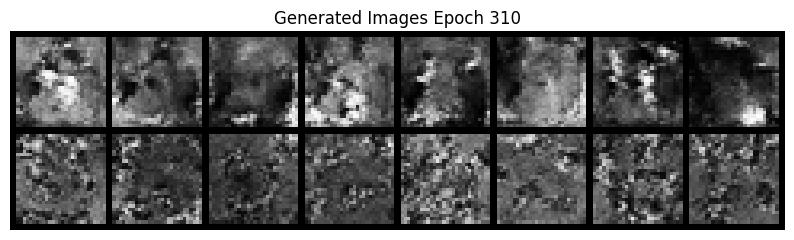

[Epoch 311/400] [Loss D: 0.6528] [Loss G: 2.2428]
[Epoch 312/400] [Loss D: 0.5459] [Loss G: 3.4176]
[Epoch 313/400] [Loss D: 0.5714] [Loss G: 3.2166]
[Epoch 314/400] [Loss D: 0.4829] [Loss G: 3.0721]
[Epoch 315/400] [Loss D: 0.5516] [Loss G: 2.6532]


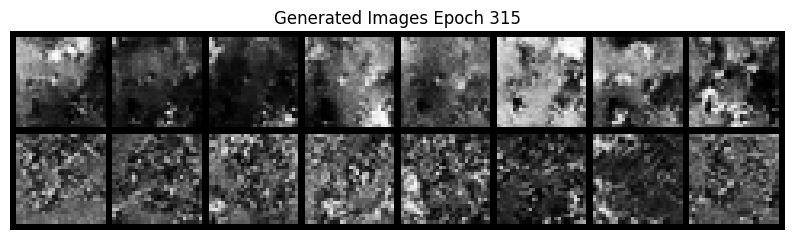

[Epoch 316/400] [Loss D: 0.4400] [Loss G: 3.0740]
[Epoch 317/400] [Loss D: 0.5204] [Loss G: 2.6982]
[Epoch 318/400] [Loss D: 0.5595] [Loss G: 3.4037]
[Epoch 319/400] [Loss D: 0.4440] [Loss G: 3.8813]
[Epoch 320/400] [Loss D: 0.4621] [Loss G: 3.2505]
--- Menghitung FID Score Manual pada Epoch 320 ---
>> Real-FID Score di Epoch 320: 103.3492





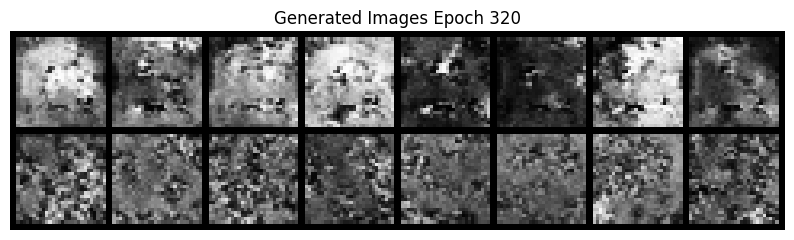

[Epoch 321/400] [Loss D: 0.5773] [Loss G: 2.6360]
[Epoch 322/400] [Loss D: 0.5280] [Loss G: 3.5837]
[Epoch 323/400] [Loss D: 0.4631] [Loss G: 3.4480]
[Epoch 324/400] [Loss D: 0.4401] [Loss G: 3.8415]
[Epoch 325/400] [Loss D: 0.3745] [Loss G: 2.9160]


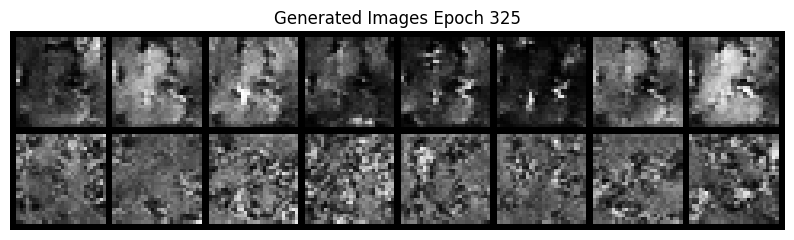

[Epoch 326/400] [Loss D: 0.4672] [Loss G: 2.9843]
[Epoch 327/400] [Loss D: 0.5594] [Loss G: 2.2550]
[Epoch 328/400] [Loss D: 0.6392] [Loss G: 3.7386]
[Epoch 329/400] [Loss D: 0.4856] [Loss G: 2.6744]
[Epoch 330/400] [Loss D: 0.4343] [Loss G: 3.1162]
--- Menghitung FID Score Manual pada Epoch 330 ---
>> Real-FID Score di Epoch 330: 111.1203





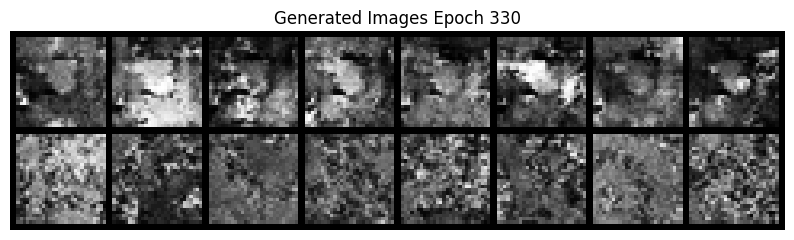

[Epoch 331/400] [Loss D: 0.4362] [Loss G: 3.0609]
[Epoch 332/400] [Loss D: 0.4464] [Loss G: 2.9745]
[Epoch 333/400] [Loss D: 0.5054] [Loss G: 2.8944]
[Epoch 334/400] [Loss D: 0.4618] [Loss G: 3.1380]
[Epoch 335/400] [Loss D: 0.4806] [Loss G: 3.0910]


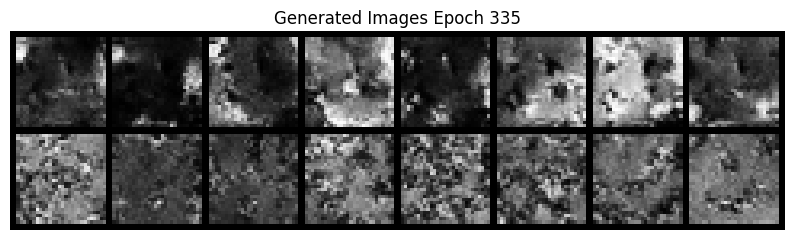

[Epoch 336/400] [Loss D: 0.5387] [Loss G: 3.8261]
[Epoch 337/400] [Loss D: 0.6086] [Loss G: 3.0731]
[Epoch 338/400] [Loss D: 0.5689] [Loss G: 3.1220]
[Epoch 339/400] [Loss D: 0.5386] [Loss G: 3.5584]
[Epoch 340/400] [Loss D: 0.5257] [Loss G: 2.8123]
--- Menghitung FID Score Manual pada Epoch 340 ---
>> Real-FID Score di Epoch 340: 89.8365





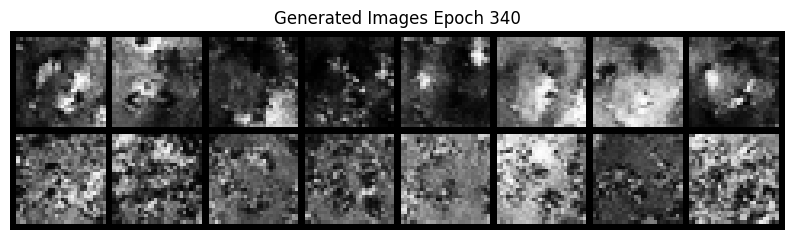

[Epoch 341/400] [Loss D: 0.4769] [Loss G: 2.5821]
[Epoch 342/400] [Loss D: 0.4498] [Loss G: 3.7750]
[Epoch 343/400] [Loss D: 0.4253] [Loss G: 3.3118]
[Epoch 344/400] [Loss D: 0.4798] [Loss G: 2.6049]
[Epoch 345/400] [Loss D: 0.4157] [Loss G: 3.3692]


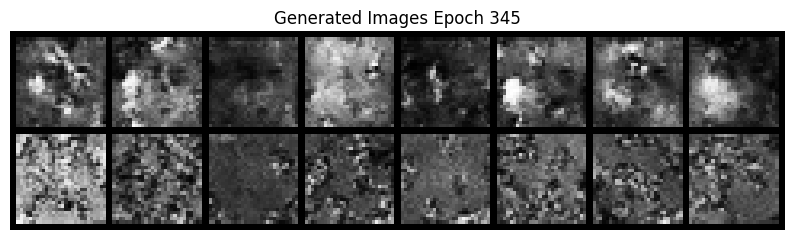

[Epoch 346/400] [Loss D: 0.5076] [Loss G: 3.0019]
[Epoch 347/400] [Loss D: 0.4202] [Loss G: 2.9257]
[Epoch 348/400] [Loss D: 0.4728] [Loss G: 2.7696]
[Epoch 349/400] [Loss D: 0.4443] [Loss G: 2.8880]
[Epoch 350/400] [Loss D: 0.4524] [Loss G: 2.8031]
--- Menghitung FID Score Manual pada Epoch 350 ---
>> Real-FID Score di Epoch 350: 79.8333





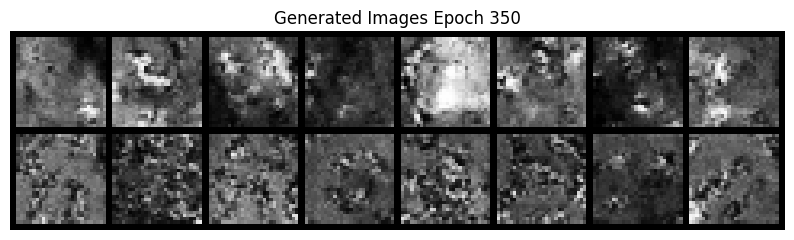

[Epoch 351/400] [Loss D: 0.4759] [Loss G: 2.6006]
[Epoch 352/400] [Loss D: 0.5450] [Loss G: 2.7145]
[Epoch 353/400] [Loss D: 0.3919] [Loss G: 3.0664]
[Epoch 354/400] [Loss D: 0.4780] [Loss G: 3.0778]
[Epoch 355/400] [Loss D: 0.5765] [Loss G: 2.6228]


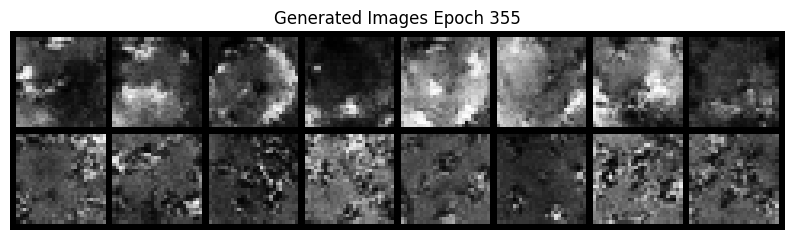

[Epoch 356/400] [Loss D: 0.5170] [Loss G: 2.6106]
[Epoch 357/400] [Loss D: 0.5910] [Loss G: 2.6124]
[Epoch 358/400] [Loss D: 0.3993] [Loss G: 3.1653]
[Epoch 359/400] [Loss D: 0.4506] [Loss G: 3.2011]
[Epoch 360/400] [Loss D: 0.4229] [Loss G: 3.4409]
--- Menghitung FID Score Manual pada Epoch 360 ---
>> Real-FID Score di Epoch 360: 62.2314





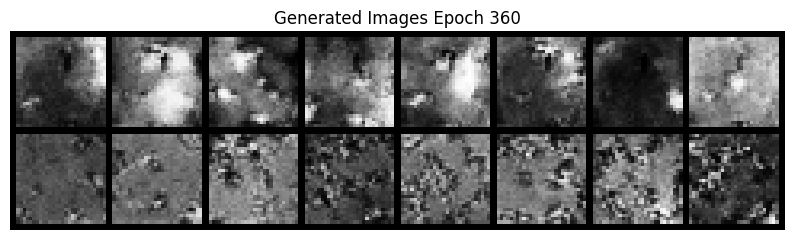

[Epoch 361/400] [Loss D: 0.4693] [Loss G: 2.7536]
[Epoch 362/400] [Loss D: 0.4679] [Loss G: 3.5905]
[Epoch 363/400] [Loss D: 0.4443] [Loss G: 2.8516]
[Epoch 364/400] [Loss D: 0.4403] [Loss G: 2.7926]
[Epoch 365/400] [Loss D: 0.5549] [Loss G: 3.7360]


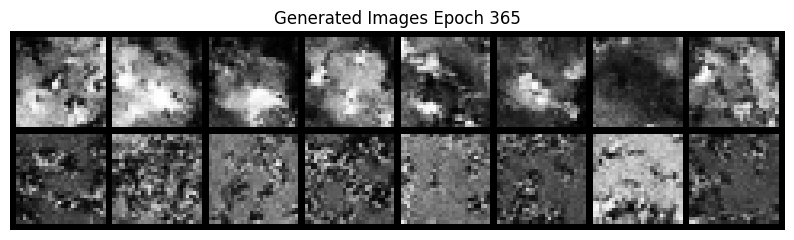

[Epoch 366/400] [Loss D: 0.4735] [Loss G: 3.0490]
[Epoch 367/400] [Loss D: 0.5176] [Loss G: 3.8009]
[Epoch 368/400] [Loss D: 0.3536] [Loss G: 3.2090]
[Epoch 369/400] [Loss D: 0.4066] [Loss G: 3.2612]
[Epoch 370/400] [Loss D: 0.3821] [Loss G: 3.0762]
--- Menghitung FID Score Manual pada Epoch 370 ---
>> Real-FID Score di Epoch 370: 73.1882





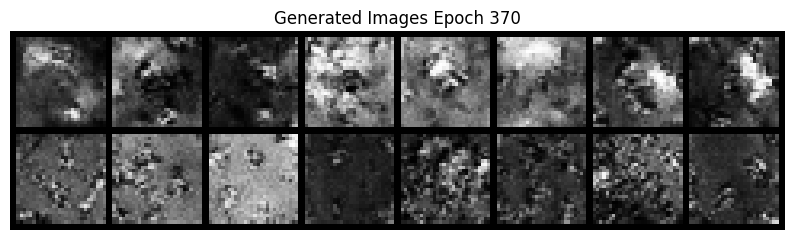

[Epoch 371/400] [Loss D: 0.3983] [Loss G: 3.3529]
[Epoch 372/400] [Loss D: 0.4205] [Loss G: 2.9847]
[Epoch 373/400] [Loss D: 0.4431] [Loss G: 3.5457]
[Epoch 374/400] [Loss D: 0.4848] [Loss G: 3.6499]
[Epoch 375/400] [Loss D: 0.4138] [Loss G: 3.1964]


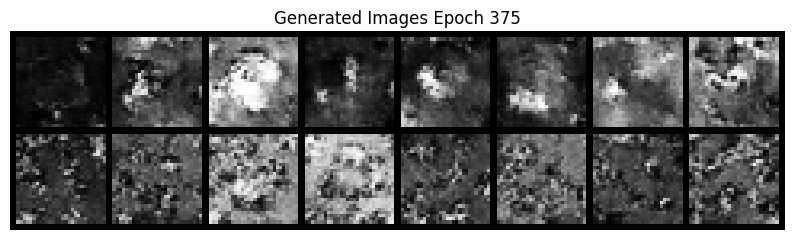

[Epoch 376/400] [Loss D: 0.4645] [Loss G: 3.1107]
[Epoch 377/400] [Loss D: 0.4547] [Loss G: 3.2832]
[Epoch 378/400] [Loss D: 0.4314] [Loss G: 3.0268]
[Epoch 379/400] [Loss D: 0.4205] [Loss G: 3.0961]
[Epoch 380/400] [Loss D: 0.3776] [Loss G: 3.6171]
--- Menghitung FID Score Manual pada Epoch 380 ---
>> Real-FID Score di Epoch 380: 90.5381





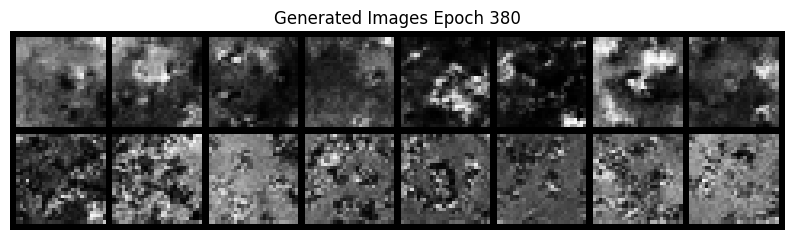

[Epoch 381/400] [Loss D: 0.6244] [Loss G: 4.0120]
[Epoch 382/400] [Loss D: 0.4676] [Loss G: 3.5707]
[Epoch 383/400] [Loss D: 0.4486] [Loss G: 2.4506]
[Epoch 384/400] [Loss D: 0.3920] [Loss G: 3.7093]
[Epoch 385/400] [Loss D: 0.4827] [Loss G: 3.0938]


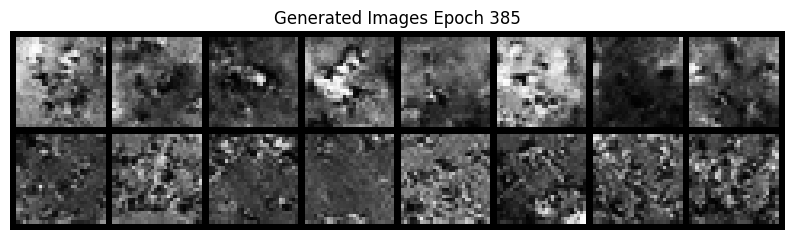

[Epoch 386/400] [Loss D: 0.4679] [Loss G: 2.6414]
[Epoch 387/400] [Loss D: 0.4307] [Loss G: 2.8930]
[Epoch 388/400] [Loss D: 0.4441] [Loss G: 3.7397]
[Epoch 389/400] [Loss D: 0.3876] [Loss G: 3.5974]
[Epoch 390/400] [Loss D: 0.3585] [Loss G: 3.4218]
--- Menghitung FID Score Manual pada Epoch 390 ---
>> Real-FID Score di Epoch 390: 113.2155





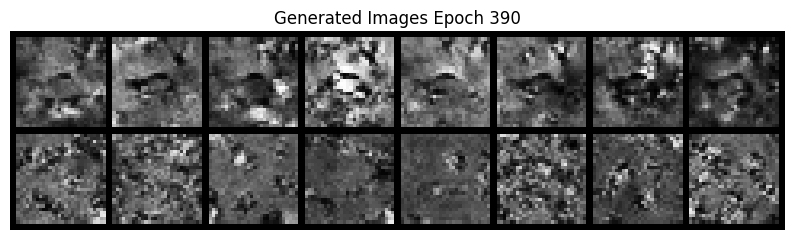

[Epoch 391/400] [Loss D: 0.4360] [Loss G: 3.2994]
[Epoch 392/400] [Loss D: 0.4385] [Loss G: 3.7255]
[Epoch 393/400] [Loss D: 0.4184] [Loss G: 3.6953]
[Epoch 394/400] [Loss D: 0.4185] [Loss G: 3.3318]
[Epoch 395/400] [Loss D: 0.3748] [Loss G: 4.4204]


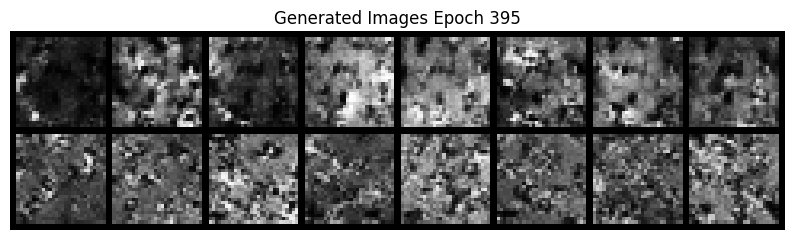

[Epoch 396/400] [Loss D: 0.3810] [Loss G: 3.2574]
[Epoch 397/400] [Loss D: 0.3363] [Loss G: 3.5686]
[Epoch 398/400] [Loss D: 0.3713] [Loss G: 3.0709]
[Epoch 399/400] [Loss D: 0.4106] [Loss G: 3.5253]
[Epoch 400/400] [Loss D: 0.3476] [Loss G: 4.1988]
--- Menghitung FID Score Manual pada Epoch 400 ---
>> Real-FID Score di Epoch 400: 100.7746





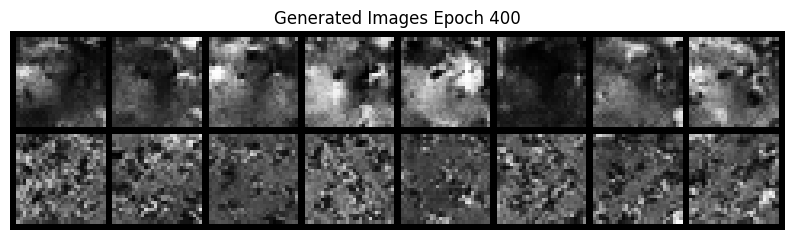

In [ ]:
# Hyperparameters
NUM_EPOCHS = 400
FID_INTERVAL = 10  # Hitung FID setiap 10 epoch
SAMPLE_INTERVAL = 5

losses_G = []
losses_D = []
fid_scores = []

best_fid = float('inf')  # Inisialisasi dengan nilai tertinggi
checkpoint_path = 'best_cgan_model.pth'

print("Memulai Pelatihan CGAN dengan Evaluasi FID...")

for epoch in range(NUM_EPOCHS):
    generator.train()
    discriminator.train()

    for i, (real_imgs, labels) in enumerate(dataloader):
        batch_size = real_imgs.size(0)

        real_imgs = real_imgs.to(device)
        labels = labels.to(device)

        # Smoothing dari 1 -> 0.95
        real_target = torch.ones(batch_size, 1).to(device) * 0.95
        fake_target = torch.zeros(batch_size, 1).to(device)

        #Latih Diskriminator
        optimizer_D.zero_grad()

        output_real = discriminator(real_imgs, labels)
        loss_D_real = criterion(output_real, real_target)

        noise = torch.randn(batch_size, NOISE_DIM).to(device)
        fake_imgs = generator(noise, labels)

        output_fake = discriminator(fake_imgs.detach(), labels)
        loss_D_fake = criterion(output_fake, fake_target)

        loss_D = loss_D_real + loss_D_fake
        loss_D.backward()
        optimizer_D.step()

        #Latihan Generator
        optimizer_G.zero_grad()

        output_fake_for_G = discriminator(fake_imgs, labels)
        loss_G = criterion(output_fake_for_G, real_target)

        loss_G.backward()
        optimizer_G.step()

    losses_D.append(loss_D.item())
    losses_G.append(loss_G.item())

    print(f"[Epoch {epoch+1}/{NUM_EPOCHS}] [Loss D: {loss_D.item():.4f}] [Loss G: {loss_G.item():.4f}]")

    if (epoch + 1) % FID_INTERVAL == 0:
        generator.eval()

        all_real_features = []
        all_fake_features = []

        print(f"--- Menghitung FID Score Manual pada Epoch {epoch+1} ---")
        with torch.no_grad():
            for real_batch_imgs, batch_labels in dataloader:
                batch_size = real_batch_imgs.size(0)
                real_batch_imgs = real_batch_imgs.to(device)
                batch_labels = batch_labels.to(device)

                # Generate gambar palsu
                z = torch.randn(batch_size, NOISE_DIM).to(device)
                fake_batch_imgs = generator(z, batch_labels)

                # Flatten
                real_flat = real_batch_imgs.view(batch_size, -1).cpu().numpy()
                fake_flat = fake_batch_imgs.view(batch_size, -1).cpu().numpy()

                all_real_features.append(real_flat)
                all_fake_features.append(fake_flat)

        # Gabungkan semua batch ke array
        all_real_features = np.concatenate(all_real_features, axis=0)
        all_fake_features = np.concatenate(all_fake_features, axis=0)

        # Hitung skor FID 
        epoch_fid = calculate_numpy_fid(all_real_features, all_fake_features)
        fid_scores.append((epoch + 1, epoch_fid))
        print(f">> Real-FID Score di Epoch {epoch+1}: {epoch_fid:.4f}\n")

        if epoch_fid < best_fid: #Checkpoint
            best_fid = epoch_fid
            print(f"--> [SAVE] FID membaik! Menyimpan model terbaik ke {checkpoint_path}...")

            # Menyimpan state_dict kedua model dan optimizer secara bersamaan
            torch.save({
                'epoch': epoch + 1,
                'generator_state_dict': generator.state_dict(),
                'discriminator_state_dict': discriminator.state_dict(),
                'optimizer_G_state_dict': optimizer_G.state_dict(),
                'optimizer_D_state_dict': optimizer_D.state_dict(),
                'best_fid': best_fid,
            }, checkpoint_path)
        print("\n")

    # Cetak sampel gambar tiap 5 epoch
    if (epoch + 1) % SAMPLE_INTERVAL == 0:
        generator.eval()
        with torch.no_grad():
            sample_noise = torch.randn(16, NOISE_DIM).to(device)
            sample_labels = torch.cat([torch.zeros(8), torch.ones(8)]).long().to(device)
            gen_imgs = generator(sample_noise, sample_labels)
            gen_imgs = (gen_imgs + 1) / 2

            grid = vutils.make_grid(gen_imgs.cpu(), nrow=8, normalize=True)
            plt.figure(figsize=(10, 4))
            plt.imshow(grid.permute(1, 2, 0).numpy())
            plt.title(f"Generated Images Epoch {epoch+1}")
            plt.axis('off')
            plt.show()

#### C.4 Loss Plot

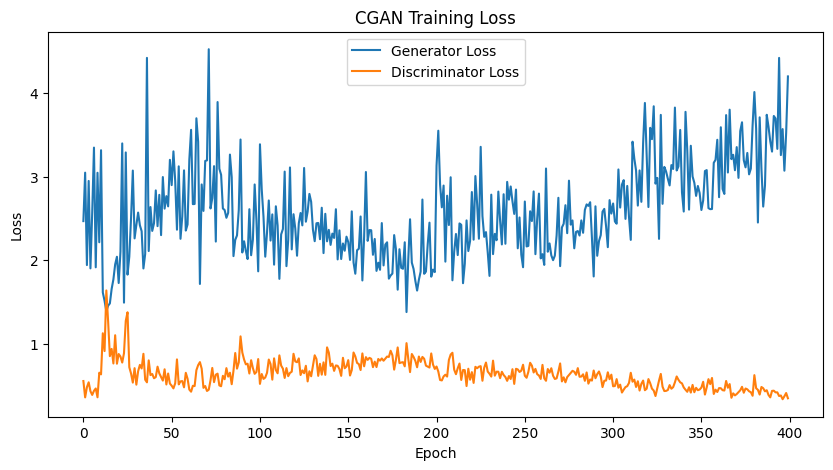

In [204]:
plt.figure(figsize=(10, 5))
plt.plot(losses_G, label="Generator Loss")
plt.plot(losses_D, label="Discriminator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.title("CGAN Training Loss")
plt.show()

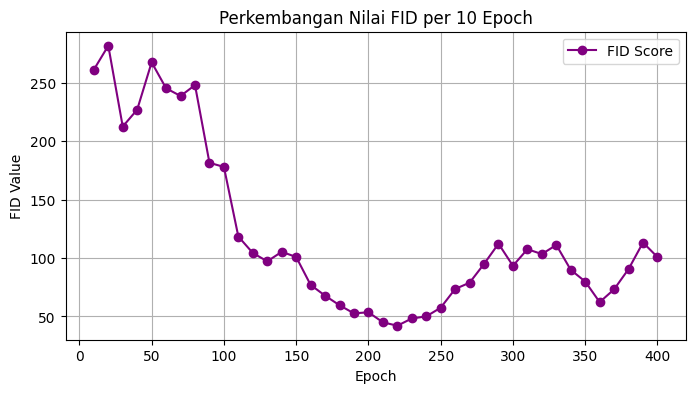

In [205]:
if fid_scores:
    epochs_fid, scores_fid = zip(*fid_scores)
    plt.figure(figsize=(8, 4))
    plt.plot(epochs_fid, scores_fid, marker='o', color='purple', label='FID Score')
    plt.xlabel("Epoch")
    plt.ylabel("FID Value")
    plt.title("Perkembangan Nilai FID per 10 Epoch")
    plt.grid(True)
    plt.legend()
    plt.show()

#### C.5 Checkpoint Model

In [206]:
# Mematikan validasi strict weights_only
checkpoint = torch.load('/content/best_cgan_model.pth', weights_only=False)

generator.load_state_dict(checkpoint['generator_state_dict'])
discriminator.load_state_dict(checkpoint['discriminator_state_dict'])

print(f"Model terbaik berhasil dimuat dari Epoch {checkpoint['epoch']} dengan FID: {checkpoint['best_fid']:.4f}")

Model terbaik berhasil dimuat dari Epoch 220 dengan FID: 42.0508


### D. Conclusion

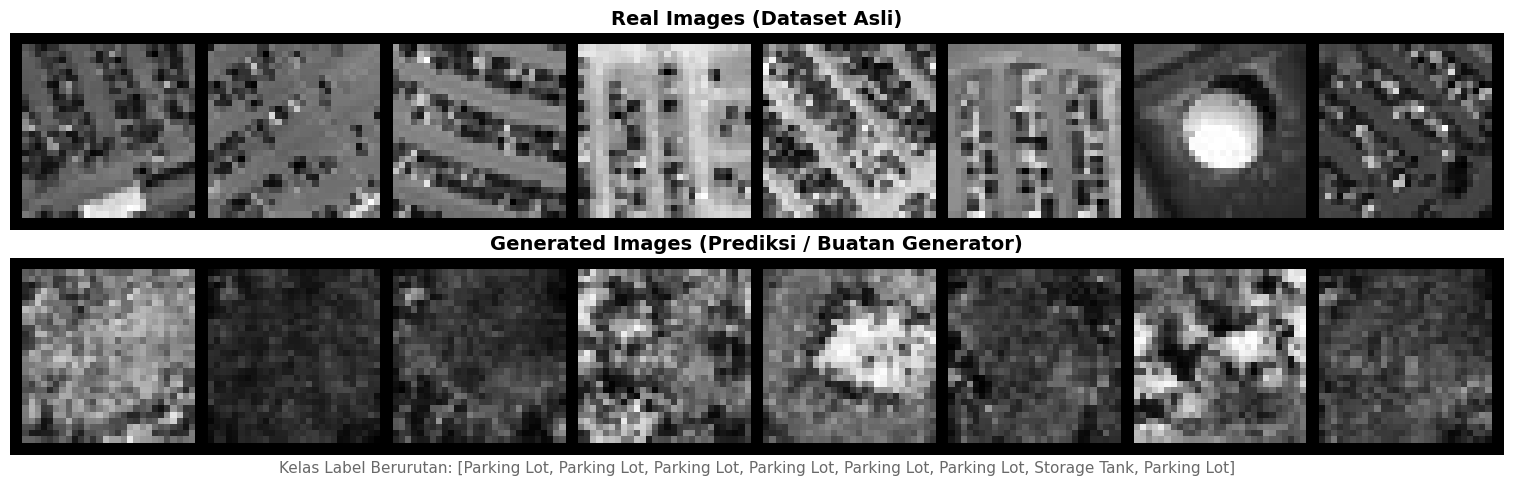

In [ ]:
import matplotlib.pyplot as plt
import torchvision.utils as vutils
import numpy as np

def plot_real_vs_fake(dataloader, generator, noise_dim, num_images=8):
    real_imgs, labels = next(iter(dataloader))

    real_imgs = real_imgs[:num_images].to(device)
    labels = labels[:num_images].to(device)

    generator.eval()
    with torch.no_grad():
        noise = torch.randn(num_images, noise_dim).to(device)
        fake_imgs = generator(noise, labels)

    real_imgs = (real_imgs + 1) / 2.0
    fake_imgs = (fake_imgs + 1) / 2.0

    grid_real = vutils.make_grid(real_imgs.cpu(), nrow=num_images, padding=2, normalize=True)
    grid_fake = vutils.make_grid(fake_imgs.cpu(), nrow=num_images, padding=2, normalize=True)

    fig, axes = plt.subplots(2, 1, figsize=(num_images * 2, 5))

    axes[0].imshow(grid_real.permute(1, 2, 0).numpy())
    axes[0].set_title("Real Images (Dataset Asli)", fontsize=14, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(grid_fake.permute(1, 2, 0).numpy())
    axes[1].set_title("Generated Images (Prediksi / Buatan Generator)", fontsize=14, fontweight='bold')
    axes[1].axis('off')

    class_names = {0: "Storage Tank", 1: "Parking Lot"}
    lbl_text = "Kelas Label Berurutan: [" + ", ".join([class_names[lbl.item()] for lbl in labels]) + "]"
    plt.suptitle(lbl_text, fontsize=11, y=0.02, color='dimgray')

    plt.tight_layout()
    plt.show()

#Gunakan model checkpoint
plot_real_vs_fake(dataloader, generator, noise_dim=NOISE_DIM, num_images=8)

Evaluasi Akhir:

1. Karakteristik Arsitektur Generator & Fungsi Aktivasi Tanh, Efek Blurring Ringan - model cenderung menghasilkan transisi gradien piksel yang halus jika kapasitas fiturnya masih terbatas.Hal ini menyebabkan lingkaran luar pada objek Storage Tank (seperti pada kolom 1, 4, dan 6) tidak memiliki garis batas yang tegas dan warnanya agak membaur dengan tekstur tanah di sekitarnya.

2. Kompleksitas Spasial Data Kolom 3 & 5 (Parking Lot): Pada kolom 3 dan 5 yang berlabel Parking Lot. Pada gambar aslinya (Real), kelas ini memiliki fitur garis-garis sejajar yang sangat rapat (pola parkiran kendaraan atau garis atap gedung). Pola berulang dengan frekuensi spasial tinggi (high-frequency spatial details) seperti ini adalah musuh terbesar bagi GAN standar. Generator kesulitan menggambar garis lurus tipis setebal 1-2 piksel pada resolusi $28 \times 28$. Akibatnya, dibanding memunculkan pola berulang, Generator memprediksinya sebagai tekstur abu-abu acak yang menyatu dengan sekelilingnya.

3. Kontras Tinggi pada Kolom 4: Pada gambar buatan kolom 4, Generator mencoba meniru objek lingkaran putih Storage Tank yang besar. Namun, karena pemetaan fiturnya belum sempurna, warna putihnya melebar secara ekstrem dan merusak bentuk tepi lingkaran (blobbing effect).

Meskipun skor FID bertindak sebagai metrik evaluasi kuantitatif utama untuk mengukur kedekatan distribusi statistik, nilai FID tidak selalu selaras secara linier dengan kualitas struktural spasial (kualitatif).

 Pada epoch-epoch terakhir seperti 395 & 400, didapatkan bahwa tepi objek (edges) terlihat lebih defined dan terstruktur dengan baik bagi persepsi visual, meskipun skor FID mengalami sedikit kenaikan. Hal ini membuktikan adanya trade-off antara konvergesi statistik global (FID) dengan ketajaman fitur lokal (high-frequency structural details) pada pemetaan citra oleh Generator. 

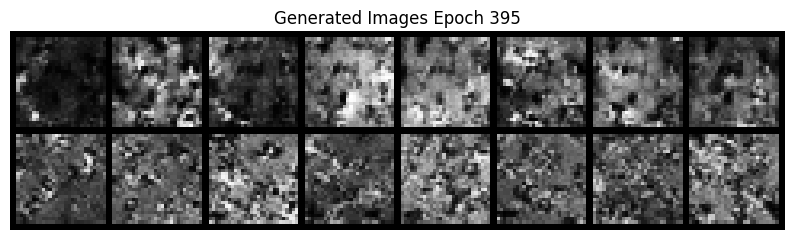 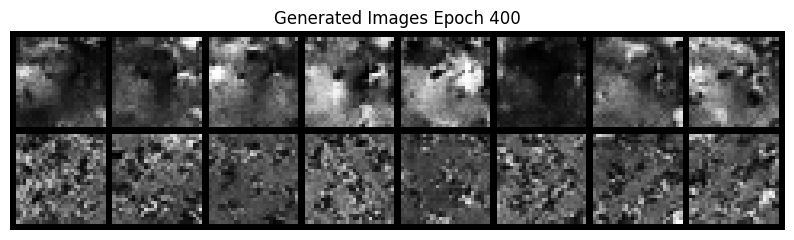